<h1 align="center">Problem Set: Data exploration</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain 2026&mdash; SOLUTIONS</h3>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Overview</h2>

Over the course of this problem set you will work with a single two-photon imaging session
from the **Allen Brain Observatory &mdash; Visual Behavior Ophys** dataset. A mouse performs a
visual change detection task: it is shown a stream of natural images and must lick when the
identity of the image changes.

Everything here is read **directly out of the NWB file** using `h5py`. We deliberately do not
use the AllenSDK. Two reasons:

1. NWB is the community standard for neurophysiology data. If you can navigate an NWB file
   you can work with data from labs that have never heard of the AllenSDK.
2. Understanding what an SDK is doing for you &mdash; and what it is hiding from you &mdash; is
   worth the extra twenty lines of code.

<h3>The three questions</h3>

**Question 1.** Someone else's group published this dataset with a README and a set of summary
figures. Read the data, work out what is in it, and replicate their figures.

**Question 2.** Build a PSTH. Look at how a handful of individual cells respond to the image
change, and think carefully about variability &mdash; across trials, and across neurons.

**Question 3.** Quantify pairwise correlations across the population in one condition and
compare to another condition. Does the correlation structure of the population change with
behavioral state or task outcome?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Summer Workshop on the Dynamic Brain Data Book</h2>

The databook describes the dimensions of the dataset, the methods used to collect it, and how
to access it. The pages for the Visual Behavior Ophys dataset are here:
https://allenswdb.github.io/physiology/ophys/visual-behavior/VB-Ophys.html

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Setup</h2>

</div>

In [1]:
# general imports
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.ndimage import gaussian_filter1d

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

We will use two functions from the Allen Institute's `brain_observatory_utilities`
package later on (Questions 2 and 3). The cell below imports it, installing it from GitHub at a
pinned commit if it is not already available.

Note the `--no-deps` flag: the package declares `allensdk` as a dependency, but the two
functions we want (`event_triggered_response` and `get_stimulus_response_df`) only need numpy,
pandas and xarray. We are keeping our promise not to use the AllenSDK.

</div>

In [2]:
BOU_COMMIT = "35fbec6f155bec424f2f0b6c671710d0068e7661"

try:
    import brain_observatory_utilities  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "--no-deps",
                    f"git+https://github.com/AllenInstitute/brain_observatory_utilities.git@{BOU_COMMIT}"],
                   check=True)

from brain_observatory_utilities.utilities.general_utilities import event_triggered_response
from brain_observatory_utilities.datasets.optical_physiology import data_formatting as ophys_formatting

print("brain_observatory_utilities ready")

brain_observatory_utilities ready


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Where is the data?</h3>

The Visual Behavior Ophys dataset is attached to this capsule as a Code Ocean data asset, which
appears under `/data/`. The cell below finds it whether you are on Code Ocean, on a local
machine with the workshop hard drive, or working from a local download.

</div>

In [ ]:
# Which experiment are we looking at?
# OPHYS_1_images_A, VisualBehaviorMultiscope, Slc17a7-IRES2-Cre (excitatory cells in visual cortex)
OPHYS_EXPERIMENT_ID = 971813760

candidate_dirs = [
    "/data/visual-behavior-ophys/behavior_ophys_experiments",   # Code Ocean data asset
    "/Volumes/Brain2025/visual-behavior-ophys/behavior_ophys_experiments",  # workshop drive, macOS
    "E:/visual-behavior-ophys/behavior_ophys_experiments",      # workshop drive, Windows
    "data",                                                    # local download
]

filename = f"behavior_ophys_experiment_{OPHYS_EXPERIMENT_ID}.nwb"

nwb_path = None
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, filename)):
        nwb_path = os.path.join(d, filename)
        break

if nwb_path is None:
    raise FileNotFoundError(
        f"Could not find {filename}. Checked: {candidate_dirs}"
    )

print("NWB file:", nwb_path)
print("size: %.0f MB" % (os.path.getsize(nwb_path) / 1e6))

NWB file: data/behavior_ophys_experiment_971813760.nwb
size: 822 MB


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Question 1: Read the README, then replicate the figures</h1>

You have been handed a dataset by another group. Before you can reproduce anything you need to
answer some basic questions: what was recorded, from where, in what kind of mouse, and how
much of it is there?

In this section you will:

1. Open the NWB file and inventory its contents
2. Pull out the metadata: genotype, brain area, imaging depth, number of neurons
3. Replicate their **whole-session** figure &mdash; running speed and population activity, with
   the stimulus blocks shaded, and licks and rewards marked
4. Replicate their **zoomed-in** figure &mdash; the same signals over one minute, but now showing
   individual stimulus presentations, with image changes distinguished from image repeats

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.1 What is inside an NWB file?</h2>

An NWB file is an HDF5 file with an agreed-upon internal layout. `h5py` lets us walk it like a
nested dictionary. The top-level groups you care about are:

| group | what lives there |
|---|---|
| `/general` | metadata: subject, genotype, equipment, imaging plane |
| `/intervals` | tables of time intervals: `trials`, and the stimulus presentation tables |
| `/processing` | processed data: `ophys` (dF/F, events, ROI masks), `running`, `licking`, `rewards` |
| `/acquisition` | raw acquired signals (eye tracking, running encoder voltage) |

Let's look.

</div>

In [4]:
def show_nwb_tree(group, prefix="", max_depth=2, depth=0):
    """Recursively print the structure of an HDF5/NWB group."""
    for key in group.keys():
        item = group[key]
        path = f"{prefix}/{key}"
        if isinstance(item, h5py.Group):
            ndtype = item.attrs.get("neurodata_type", "")
            print(f"{path}/" + (f"   [{ndtype}]" if ndtype else ""))
            if depth < max_depth:
                show_nwb_tree(item, path, max_depth, depth + 1)
        else:
            print(f"{path}   shape={item.shape}")


nwb = h5py.File(nwb_path, "r")

for top in ["/general", "/intervals", "/processing"]:
    print("=" * 70)
    print(top)
    print("=" * 70)
    show_nwb_tree(nwb[top], top, max_depth=1)
    print()

/general
/general/devices/
/general/devices/MESO.1/   [Device]
/general/experiment_description   shape=()
/general/institution   shape=()
/general/keywords   shape=(5,)
/general/metadata/   [OphysBehaviorMetadata]
/general/optophysiology/
/general/optophysiology/imaging_plane_1/   [ImagingPlane]
/general/subject/   [BehaviorSubject]
/general/subject/age   shape=()
/general/subject/description   shape=()
/general/subject/genotype   shape=()
/general/subject/sex   shape=()
/general/subject/species   shape=()
/general/subject/subject_id   shape=()
/general/task_parameters/   [BehaviorTaskParameters]

/intervals
/intervals/Natural_Images_Lum_Matched_set_training_2017_presentations/   [TimeIntervals]
/intervals/Natural_Images_Lum_Matched_set_training_2017_presentations/active   shape=(4799,)
/intervals/Natural_Images_Lum_Matched_set_training_2017_presentations/duration   shape=(4799,)
/intervals/Natural_Images_Lum_Matched_set_training_2017_presentations/end_frame   shape=(4799,)
/intervals/

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.2 Helper functions for reading NWB tables</h2>

Several things in NWB are stored as *tables* &mdash; the trials table, the stimulus presentations
table, the ROI table. In HDF5 a table is a group where each column is its own dataset. Two
wrinkles:

- **Strings** come back as `bytes` and need decoding.
- **Ragged columns** (where each row holds a variable-length list, e.g. the lick times on each
  trial) are stored as one long flat array plus a companion `<column>_index` array giving the
  end position of each row.

The two functions below handle both. You will use `read_nwb_table` throughout the notebook.

</div>

In [5]:
def decode_if_bytes(array):
    """Decode an array of bytes into an array of str, leave everything else alone."""
    array = np.asarray(array)
    if array.dtype.kind in "OS":
        return np.array([x.decode() if isinstance(x, bytes) else x for x in array])
    return array


def read_nwb_table(nwb, path):
    """Read an NWB TimeIntervals / DynamicTable group into a pandas DataFrame.

    Parameters
    ----------
    nwb : h5py.File
    path : str
        e.g. "/intervals/trials"

    Returns
    -------
    pandas.DataFrame, indexed by the table's `id` column if it has one.
    """
    group = nwb[path]
    columns = {}
    n_rows = None

    # --- simple 1D columns ---
    for key in group.keys():
        dset = group[key]
        if not isinstance(dset, h5py.Dataset):
            continue
        if key.endswith("_index") or key == "timeseries":
            continue
        if dset.ndim == 1:
            columns[key] = decode_if_bytes(dset[:])

    # --- ragged columns: a flat value array + an <column>_index array of row ends ---
    for key in group.keys():
        if key.endswith("_index") and key[:-len("_index")] in group:
            base = key[:-len("_index")]
            ends = group[key][:]
            values = group[base][:]
            starts = np.concatenate([[0], ends[:-1]])
            columns[base] = [values[a:b] for a, b in zip(starts, ends)]
            n_rows = len(ends)

    if n_rows is None:
        n_rows = max(len(v) for v in columns.values())
    columns = {k: v for k, v in columns.items() if len(v) == n_rows}

    df = pd.DataFrame(columns)
    if "id" in df.columns:
        df = df.set_index("id")
    return df

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.3 Session metadata: what was recorded?</h2>

The `/general/metadata` group stores its contents as HDF5 *attributes* rather than datasets, so
we read `.attrs` instead of slicing. Subject information (genotype, sex, age) lives one level
over in `/general/subject`.

</div>

In [6]:
metadata = dict(nwb["/general/metadata"].attrs)
metadata.pop("namespace", None)
metadata.pop("neurodata_type", None)
metadata.pop("object_id", None)

for key in sorted(metadata):
    print(f"{key:30s} {metadata[key]}")

behavior_session_id            971671333
behavior_session_uuid          521b3a6b-9e40-4a0e-b0af-47ff53a5cbcc
equipment_name                 MESO.1
field_of_view_height           512
field_of_view_width            512
imaging_depth                  275
imaging_plane_group            1
imaging_plane_group_count      4
ophys_container_id             1018027828
ophys_experiment_id            971813760
ophys_session_id               971632311
project_code                   VisualBehaviorMultiscope
session_type                   OPHYS_1_images_A
stimulus_frame_rate            60.0
targeted_imaging_depth         272


In [7]:
# Subject information
subject = {key: nwb[f"/general/subject/{key}"][()].decode()
           for key in nwb["/general/subject"].keys()}

for key in sorted(subject):
    print(f"{key:12s} {subject[key]}")

age          P106D
description  A visual behavior subject with a LabTracks ID
genotype     Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-GCaMP6f)/wt
sex          M
species      Mus musculus
subject_id   484627


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** The imaging plane group holds the recording geometry. Print the brain area
(`location`), the imaging rate, the indicator, and the excitation wavelength for
`/general/optophysiology/imaging_plane_1`.

What brain area is this? What is the calcium indicator?

</div>

In [8]:
plane = nwb["/general/optophysiology/imaging_plane_1"]

for key in ["location", "indicator", "imaging_rate", "excitation_lambda", "description"]:
    value = plane[key][()]
    if isinstance(value, bytes):
        value = value.decode()
    print(f"{key:20s} {value}")

location             VISp
indicator            GCaMP6f
imaging_rate         11.0
excitation_lambda    910.0
description          (512, 512) field of view in VISp at depth 275 um


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

So: a **mesoscope** (`MESO.1`) recording from **VISp** at a targeted depth of **272 um**, in a
**Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93** mouse. `Slc17a7` is the vesicular glutamate transporter
Vglut1 &mdash; this driver line labels **excitatory** cortical neurons. The indicator is GCaMP6f.

One important consequence of the mesoscope: this file is **one imaging plane out of eight**
collected simultaneously in the same session (4 depths x 2 areas). The `ophys_session_id`
groups them, while each `ophys_experiment_id` is a single plane. So when we ask "how many
neurons are in this recording", the answer is per-plane, not per-session.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.4 How many neurons?</h2>

The ROI table (`cell_specimen_table`) has one row per segmented cell, with its mask, its
position in the field of view, and a `valid_roi` flag from the segmentation classifier.

In publicly released NWB files, invalid ROIs have already been filtered out &mdash; so
`valid_roi` should be `True` everywhere. Always check rather than assume.

</div>

In [9]:
cell_specimen_table = read_nwb_table(nwb, "/processing/ophys/image_segmentation/cell_specimen_table")

print("ROI table shape:", cell_specimen_table.shape)
print("columns:", list(cell_specimen_table.columns))
print()
print("number of ROIs:      ", len(cell_specimen_table))
print("number valid:        ", int(cell_specimen_table["valid_roi"].sum()))
print("field of view (h x w):", metadata["field_of_view_height"], "x", metadata["field_of_view_width"])

cell_specimen_table.head()

ROI table shape: (329, 11)
columns: ['cell_specimen_id', 'height', 'mask_image_plane', 'max_correction_down', 'max_correction_left', 'max_correction_right', 'max_correction_up', 'valid_roi', 'width', 'x', 'y']

number of ROIs:       329
number valid:         329
field of view (h x w): 512 x 512


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.5 The activity traces</h2>

There are two representations of neural activity in this file, and the difference matters for
Questions 2 and 3:

- **`/processing/ophys/dff`** &mdash; dF/F, a continuous trace. Fluorescence relative to a rolling
  baseline. This is the closest thing to "the signal", but calcium fluorescence decays slowly,
  so dF/F is a smeared version of the underlying spiking.
- **`/processing/ophys/event_detection`** &mdash; detected events. A *sparse* trace: mostly zeros,
  with a nonzero magnitude at timepoints where the algorithm inferred a burst of spiking. This
  group also stores a per-cell `noise_stds`, which we will use in Question 2.

Both are stored as `(n_timepoints, n_cells)` arrays sharing one timestamp vector.

</div>

In [10]:
ophys_timestamps = nwb["/processing/ophys/dff/traces/timestamps"][:]
dff_traces = nwb["/processing/ophys/dff/traces/data"][:]

events_traces = nwb["/processing/ophys/event_detection/data"][:]
events_noise_stds = nwb["/processing/ophys/event_detection/noise_stds"][:]

ophys_frame_rate = 1.0 / np.median(np.diff(ophys_timestamps))

print("dff traces:      ", dff_traces.shape, "(timepoints, cells)")
print("events traces:   ", events_traces.shape)
print("timestamps:      ", ophys_timestamps.shape)
print("ophys frame rate: %.2f Hz" % ophys_frame_rate)
print("session duration: %.1f min" % ((ophys_timestamps[-1] - ophys_timestamps[0]) / 60))
print()
print("fraction of events timepoints that are zero: %.3f" % np.mean(events_traces == 0))

dff traces:       (48298, 329) (timepoints, cells)
events traces:    (48298, 329)
timestamps:       (48298,)
ophys frame rate: 10.73 Hz
session duration: 75.1 min

fraction of events timepoints that are zero: 0.995


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.6 Behavior: stimulus, trials, licks, rewards, running</h2>

Now the behavioral side of the file.

**Stimulus presentations.** In `/intervals` there is one presentations table per stimulus type.
This session has three: the natural images shown during the task, a natural movie shown at the
end, and the gray-screen "spontaneous" periods. We concatenate them into one table sorted by
time, which is what the AllenSDK would hand you as `stimulus_presentations`.

**Trials.** `/intervals/trials` has one row per behavioral trial, with the outcome flags
(`hit`, `miss`, `false_alarm`, `correct_reject`, `aborted`, `auto_rewarded`).

</div>

In [11]:
# Concatenate all stimulus presentation tables into one time-sorted table
presentation_keys = [k for k in nwb["/intervals"].keys() if k.endswith("_presentations")]
print("presentation tables found:", presentation_keys)

stimulus_presentations = pd.concat(
    [read_nwb_table(nwb, f"/intervals/{k}") for k in presentation_keys]
).sort_values("start_time").reset_index(drop=True)
stimulus_presentations.index.name = "stimulus_presentations_id"

# these columns hold NaN outside the change detection block, so they load as float
for column in ["is_change", "omitted", "is_image_novel"]:
    if column in stimulus_presentations.columns:
        stimulus_presentations[column] = stimulus_presentations[column].fillna(0).astype(bool)

print("stimulus_presentations:", stimulus_presentations.shape)
stimulus_presentations.head()

presentation tables found: ['Natural_Images_Lum_Matched_set_training_2017_presentations', 'natural_movie_one_presentations', 'spontaneous_presentations']
stimulus_presentations: (13801, 20)


In [12]:
trials = read_nwb_table(nwb, "/intervals/trials")

print("trials:", trials.shape)
print()
outcome_columns = ["hit", "miss", "false_alarm", "correct_reject", "aborted", "auto_rewarded"]
print(trials[outcome_columns].sum().to_string())

trials[["start_time", "change_time", "initial_image_name", "change_image_name",
        "hit", "miss", "response_latency"]].head()

trials: (604, 21)

hit               128
miss              108
false_alarm         8
correct_reject     25
aborted           330
auto_rewarded       5


In [13]:
# Licks, rewards and running are stored as TimeSeries under /processing
lick_times = nwb["/processing/licking/licks/timestamps"][:]
reward_times = nwb["/processing/rewards/volume/timestamps"][:]

running_speed = nwb["/processing/running/speed/data"][:]
running_timestamps = nwb["/processing/running/speed/timestamps"][:]

print("licks:   ", len(lick_times))
print("rewards: ", len(reward_times))
print("running: ", running_speed.shape, "at %.1f Hz" % (1 / np.median(np.diff(running_timestamps))))

licks:    2171
rewards:  133
running:  (269964,) at 60.0 Hz


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Stimulus blocks</h3>

A session is not one continuous experiment &mdash; it is a sequence of **blocks**. Each row of the
stimulus presentations table carries a `stimulus_block_name`. Finding the start and stop time of
each block is what lets us shade them in the whole-session figure.

Note the structure of this session: **5 minutes of gray screen, the change detection task, 5
more minutes of gray screen, then a natural movie.** The two gray screen blocks bracket the
task, which is exactly the comparison we exploit in Question 3.

</div>

In [14]:
block_table = (
    stimulus_presentations
    .groupby("stimulus_block_name")
    .agg(start_time=("start_time", "min"),
         stop_time=("stop_time", "max"),
         n_presentations=("start_time", "size"))
    .sort_values("start_time")
)
block_table["duration_min"] = (block_table.stop_time - block_table.start_time) / 60

block_table

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>A title template</h3>

It is worth keeping a record of which dataset any given plot came from. Building a default title
string with the useful metadata in it saves a lot of confusion later, when you have forty
figures and no idea which mouse each one is.

</div>

In [15]:
title_template = (
    f"MID: {subject['subject_id']} | OEID: {OPHYS_EXPERIMENT_ID} | "
    f"{metadata['session_type']} | {decode_if_bytes([plane['location'][()]])[0]} "
    f"{metadata['imaging_depth']}um | {len(cell_specimen_table)} cells"
)

title_template

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.7 Figure 1: the whole session</h2>

Now we replicate their first figure. On one time axis spanning the whole session:

- running speed
- the population average activity (mean dF/F across all cells)
- the stimulus blocks, shaded
- licks and rewards, as tick marks

The population average and the running speed have very different units, so they go in stacked
panels sharing an x-axis rather than on top of each other.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the population average dF/F &mdash; the mean across all cells at each
timepoint. Then, because 10 Hz over 75 minutes is a lot of points, smooth it a little so the
slow structure is visible.

Hint: `dff_traces` is `(n_timepoints, n_cells)`, so you want to average over `axis=1`.
`gaussian_filter1d` with a sigma of a few frames works well for the smoothing.

</div>

In [16]:
population_average_dff = dff_traces.mean(axis=1)
population_average_smoothed = gaussian_filter1d(population_average_dff, sigma=10)

running_speed_smoothed = gaussian_filter1d(running_speed, sigma=60)

print("population average dff:", population_average_dff.shape)
print("mean %.4f, range %.3f to %.3f" % (population_average_dff.mean(),
                                         population_average_dff.min(),
                                         population_average_dff.max()))

population average dff: (48298,)
mean 0.0166, range -0.090 to 0.846


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Shading the blocks</h3>

We shade each stimulus block with a `axvspan`, one color per block. (The block spans a range of
*time*, which is on the x-axis, so it is a vertical span &mdash; `axvspan`, not `axhspan`.)

</div>

In [17]:
block_colors = {
    "initial_gray_screen_5min":       "lightgray",
    "change_detection_behavior":      "#B3D9F2",
    "post_behavior_gray_screen_5min": "lightgray",
    "natural_movie_one":              "#F2D9B3",
}


def shade_stimulus_blocks(ax, block_table, colors=block_colors, alpha=0.5, label=True):
    """Shade each stimulus block on `ax` as a vertical span."""
    for block_name, row in block_table.iterrows():
        ax.axvspan(row.start_time, row.stop_time,
                   color=colors.get(block_name, "lightgray"),
                   alpha=alpha, zorder=0,
                   label=block_name if label else None)

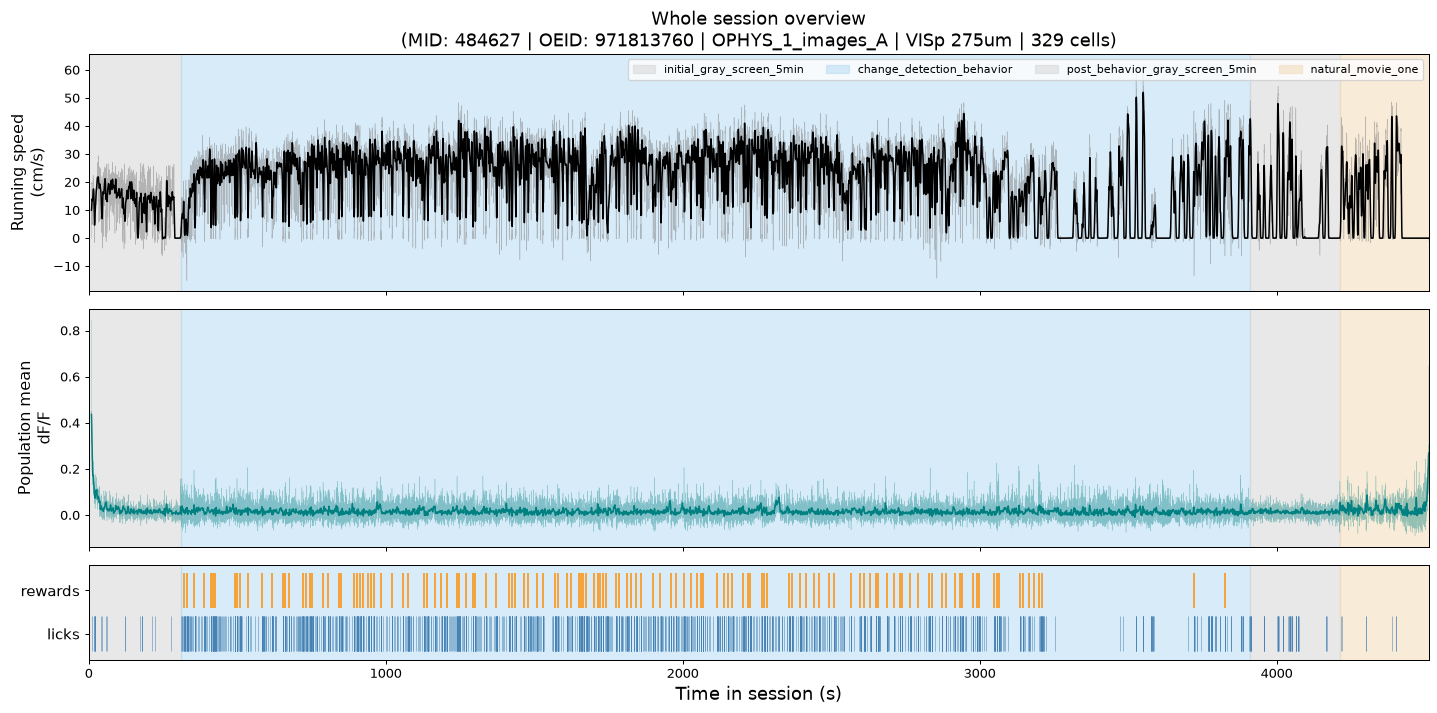

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(16, 8), sharex=True,
                       gridspec_kw={"height_ratios": [2, 2, 0.8]})

# --- running speed ---
shade_stimulus_blocks(ax[0], block_table)
ax[0].plot(running_timestamps, running_speed, lw=0.4, color="gray", alpha=0.5)
ax[0].plot(running_timestamps, running_speed_smoothed, lw=1.2, color="black")
ax[0].set_ylabel("Running speed\n(cm/s)", fontsize=13)
ax[0].legend(loc="upper right", fontsize=9, ncol=4)

# --- population average activity ---
shade_stimulus_blocks(ax[1], block_table, label=False)
ax[1].plot(ophys_timestamps, population_average_dff, lw=0.3, color="teal", alpha=0.4)
ax[1].plot(ophys_timestamps, population_average_smoothed, lw=1.2, color="teal")
ax[1].set_ylabel("Population mean\ndF/F", fontsize=13)

# --- licks and rewards as ticks ---
shade_stimulus_blocks(ax[2], block_table, label=False)
ax[2].eventplot(lick_times, lineoffsets=0.3, linelengths=0.4,
                color="steelblue", linewidths=0.4, label="licks")
ax[2].eventplot(reward_times, lineoffsets=0.8, linelengths=0.4,
                color="darkorange", linewidths=1.2, label="rewards")
ax[2].set_ylim(0, 1.1)
ax[2].set_yticks([0.3, 0.8])
ax[2].set_yticklabels(["licks", "rewards"], fontsize=12)
ax[2].set_xlabel("Time in session (s)", fontsize=14)

ax[0].set_xlim(0, ophys_timestamps[-1])
ax[0].set_title(f"Whole session overview\n({title_template})", fontsize=14)
fig.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Some things to notice, all of which are worth carrying into the rest of the analysis:

- **Licks and rewards occur only during the change detection block.** The gray screen and movie
  blocks are passive. This is why Question 3's spontaneous comparison is clean: no task, no
  licking, no reward.
- **The population average is not flat across blocks.** Activity during the task differs from
  activity during gray screen. Some of that is visual drive; some of it is arousal and running.
- **Running is intermittent**, in bouts, and the bouts do not respect block boundaries.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>1.8 Figure 2: one minute, zoomed in</h2>

The whole-session view compresses 4800 stimulus presentations into a blue smear. Their second
figure zooms into about a minute so you can see the actual task structure: images flash for
250&nbsp;ms every 750&nbsp;ms, and occasionally the image identity **changes**, which is what the
mouse must report.

We now shade each individual presentation:
- **gray** &mdash; a repeat of the same image
- **blue** &mdash; an image change

We want a window containing a few changes and at least one rewarded lick, so let's pick a window
around one of the hit trials.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose a one-minute window centered on a hit trial, and pull out the stimulus
presentations, licks and rewards that fall inside it.

Hint: `trials[trials.hit]` gives you the hit trials; `change_time` gives you when the image
changed on that trial.

</div>

In [19]:
hit_trials = trials[trials["hit"]]
print("number of hit trials:", len(hit_trials))

# pick a hit trial partway into the session and take a ~1 minute window around it
example_change_time = hit_trials["change_time"].values[20]
window_start = example_change_time - 20
window_stop = example_change_time + 40

print("window: %.1f to %.1f s (%.0f s)" % (window_start, window_stop, window_stop - window_start))

# stimulus presentations in this window, from the task block only
window_stimuli = stimulus_presentations[
    (stimulus_presentations.stimulus_block_name == "change_detection_behavior")
    & (stimulus_presentations.start_time >= window_start)
    & (stimulus_presentations.start_time < window_stop)
]

window_licks = lick_times[(lick_times >= window_start) & (lick_times < window_stop)]
window_rewards = reward_times[(reward_times >= window_start) & (reward_times < window_stop)]

print("presentations in window:", len(window_stimuli))
print("  of which changes:     ", int(window_stimuli.is_change.sum()))
print("  of which omitted:     ", int(window_stimuli.omitted.sum()))
print("licks in window:        ", len(window_licks))
print("rewards in window:      ", len(window_rewards))

window_stimuli[["start_time", "stop_time", "image_name", "is_change", "omitted"]].head(10)

number of hit trials: 128
window: 883.6 to 943.6 s (60 s)
presentations in window: 80
  of which changes:      5
  of which omitted:      5
licks in window:         70
rewards in window:       5


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Note the `omitted` column. In this task a stimulus is occasionally **omitted** &mdash; the
image simply does not appear, leaving a gap in the otherwise regular flash rhythm. Omissions are
neither repeats nor changes, so they get no shading below and appear as blank gaps.

</div>

In [20]:
def shade_stimulus_presentations(ax, window_stimuli, change_color="#4C9BE8",
                                repeat_color="lightgray", alpha=0.7):
    """Shade individual stimulus presentations: repeats gray, changes blue, omissions skipped."""
    for _, row in window_stimuli.iterrows():
        if row.omitted:
            continue
        ax.axvspan(row.start_time, row.stop_time,
                   color=change_color if row.is_change else repeat_color,
                   alpha=alpha, zorder=0)

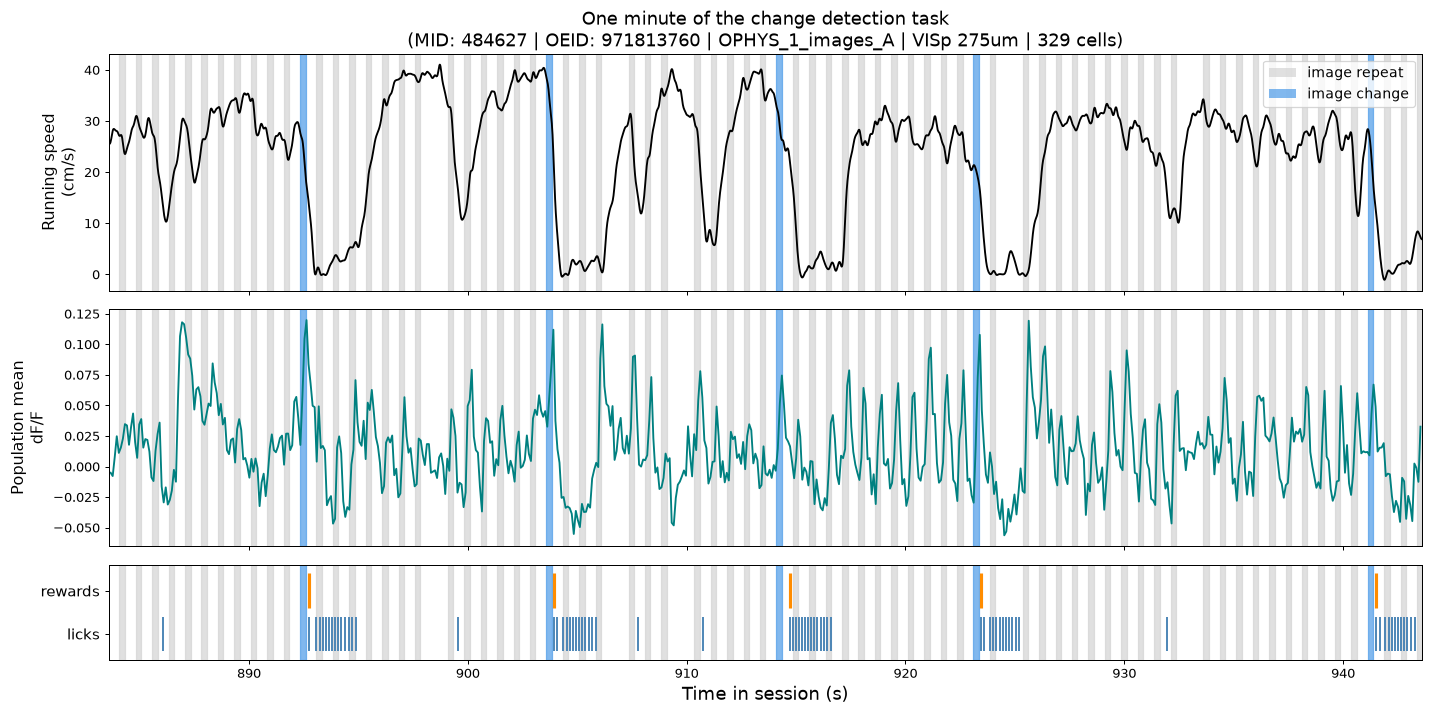

In [21]:
fig, ax = plt.subplots(3, 1, figsize=(16, 8), sharex=True,
                       gridspec_kw={"height_ratios": [2, 2, 0.8]})

window_ophys = (ophys_timestamps >= window_start) & (ophys_timestamps < window_stop)
window_running = (running_timestamps >= window_start) & (running_timestamps < window_stop)

# --- running speed ---
shade_stimulus_presentations(ax[0], window_stimuli)
ax[0].plot(running_timestamps[window_running], running_speed[window_running],
           lw=1.5, color="black")
ax[0].set_ylabel("Running speed\n(cm/s)", fontsize=13)

# --- population average activity ---
shade_stimulus_presentations(ax[1], window_stimuli)
ax[1].plot(ophys_timestamps[window_ophys], population_average_dff[window_ophys],
           lw=1.5, color="teal")
ax[1].set_ylabel("Population mean\ndF/F", fontsize=13)

# --- licks and rewards ---
shade_stimulus_presentations(ax[2], window_stimuli)
ax[2].eventplot(window_licks, lineoffsets=0.3, linelengths=0.4,
                color="steelblue", linewidths=1.5)
ax[2].eventplot(window_rewards, lineoffsets=0.8, linelengths=0.4,
                color="darkorange", linewidths=2.5)
ax[2].set_ylim(0, 1.1)
ax[2].set_yticks([0.3, 0.8])
ax[2].set_yticklabels(["licks", "rewards"], fontsize=12)
ax[2].set_xlabel("Time in session (s)", fontsize=14)

ax[0].set_xlim(window_start, window_stop)

# a legend explaining the shading
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(facecolor="lightgray", alpha=0.7, label="image repeat"),
                      Patch(facecolor="#4C9BE8", alpha=0.7, label="image change")],
             loc="upper right", fontsize=11)

ax[0].set_title(f"One minute of the change detection task\n({title_template})", fontsize=14)
fig.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Now the task structure is legible. Each gray band is a 250&nbsp;ms image flash; the blue
bands are image changes. Look at what happens after a change: a burst of licks, and (on hit
trials) a reward shortly after. And in the population average trace there is a visible bump
following the change that is larger than the response to the repeated images &mdash; the
signature we are about to quantify properly in Question 2.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Find a window containing a **miss** trial and plot it the same way. What is
different about the licking? Is there still a population response to the change?

Then try a window containing an **omission**. Can you see the gap in the stimulus rhythm?

</div>

licks within 1 s after the change: 0
rewards in this window:            4


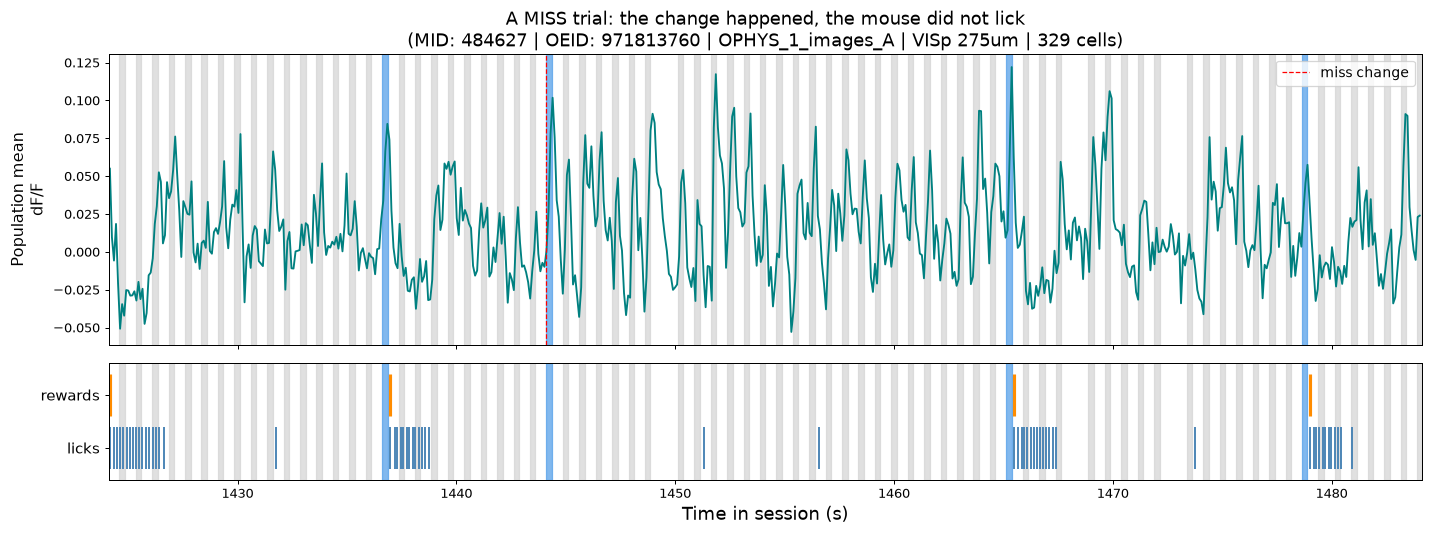

In [22]:
# --- a miss trial ---
miss_trials = trials[trials["miss"]]
miss_change_time = miss_trials["change_time"].values[10]

miss_start, miss_stop = miss_change_time - 20, miss_change_time + 40

miss_stimuli = stimulus_presentations[
    (stimulus_presentations.stimulus_block_name == "change_detection_behavior")
    & (stimulus_presentations.start_time >= miss_start)
    & (stimulus_presentations.start_time < miss_stop)
]
miss_licks = lick_times[(lick_times >= miss_start) & (lick_times < miss_stop)]
miss_rewards = reward_times[(reward_times >= miss_start) & (reward_times < miss_stop)]

fig, ax = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                       gridspec_kw={"height_ratios": [2, 0.8]})

window_ophys_miss = (ophys_timestamps >= miss_start) & (ophys_timestamps < miss_stop)

shade_stimulus_presentations(ax[0], miss_stimuli)
ax[0].plot(ophys_timestamps[window_ophys_miss], population_average_dff[window_ophys_miss],
           lw=1.5, color="teal")
ax[0].set_ylabel("Population mean\ndF/F", fontsize=13)
ax[0].axvline(miss_change_time, color="red", ls="--", lw=1, label="miss change")
ax[0].legend(loc="upper right", fontsize=11)

shade_stimulus_presentations(ax[1], miss_stimuli)
ax[1].eventplot(miss_licks, lineoffsets=0.3, linelengths=0.4, color="steelblue", linewidths=1.5)
ax[1].eventplot(miss_rewards, lineoffsets=0.8, linelengths=0.4, color="darkorange", linewidths=2.5)
ax[1].set_ylim(0, 1.1)
ax[1].set_yticks([0.3, 0.8])
ax[1].set_yticklabels(["licks", "rewards"], fontsize=12)
ax[1].set_xlabel("Time in session (s)", fontsize=14)

ax[0].set_xlim(miss_start, miss_stop)
ax[0].set_title(f"A MISS trial: the change happened, the mouse did not lick\n({title_template})",
                fontsize=14)
fig.tight_layout()

print("licks within 1 s after the change: %d" % np.sum((lick_times >= miss_change_time)
                                                       & (lick_times < miss_change_time + 1)))
print("rewards in this window:            %d" % len(miss_rewards))

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise (interpretation):** Write down two things you have learned about this dataset
that you would need to know before doing any analysis of the neural data.

*Answer:*
1. The session contains **passive blocks** (gray screen, natural movie) as well as the task. Any
   analysis has to be explicit about which block it is using, or it will silently mix task and
   non-task activity.
2. Activity comes in **two forms** (continuous dF/F and sparse detected events) that are
   appropriate for different questions, and the recording is **one plane of eight** &mdash; so
   "the population" here means ~330 cells at one depth in VISp, not the whole session.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Question 2: PSTHs and variability</h1>

The population average in Question 1 hinted that the population responds to image changes. Now
we look at individual cells, and at the thing the average threw away: **variability**.

There are two kinds of variability in play, and they are easy to conflate:

- **Across trials.** The same cell, the same stimulus, a different response every time.
- **Across neurons.** Different cells respond to the change in genuinely different ways &mdash;
  some strongly, some not at all, some with different timing.

A raster plot shows you the first. A grid of rasters shows you the second.

In this section you will:

1. Compute a signal-to-noise measure on the events traces and pick the 10 best cells
2. Extract **discrete event times** from the events traces &mdash; treating them like spike times
3. Build change-aligned rasters and PSTHs for those 10 cells
4. Do the same alignment a second way, with dF/F, using
   `brain_observatory_utilities.event_triggered_response`

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>2.1 Which cells should we look at?</h2>

With 329 cells we need a principled way to pick 10. A reasonable one: signal-to-noise on the
events trace.

The event detection group gives us `noise_stds`, the estimated noise standard deviation for each
cell. Dividing an event-magnitude statistic by it gives a per-cell SNR. We use the **mean event
magnitude over the session divided by the noise**, which favours cells that fire reliably rather
than cells with a single enormous transient.

That choice is not the only defensible one, and it matters &mdash; so we compute two versions and
compare which cells they pick.

</div>

In [23]:
snr_mean_over_noise = events_traces.mean(axis=0) / events_noise_stds
snr_max_over_noise = events_traces.max(axis=0) / events_noise_stds

cell_snr = pd.DataFrame({
    "cell_specimen_id": cell_specimen_table.index.values,
    "snr_mean_over_noise": snr_mean_over_noise,
    "snr_max_over_noise": snr_max_over_noise,
    "n_events": (events_traces > 0).sum(axis=0),
})
cell_snr.index.name = "cell_index"

print("SNR (mean/noise):  range %.3f to %.3f" % (snr_mean_over_noise.min(), snr_mean_over_noise.max()))
print("SNR (max/noise):   range %.1f to %.1f" % (snr_max_over_noise.min(), snr_max_over_noise.max()))

cell_snr.sort_values("snr_mean_over_noise", ascending=False).head(10)

SNR (mean/noise):  range 0.004 to 0.228
SNR (max/noise):   range 6.1 to 46.4


cells in the top 10 by BOTH definitions: 2


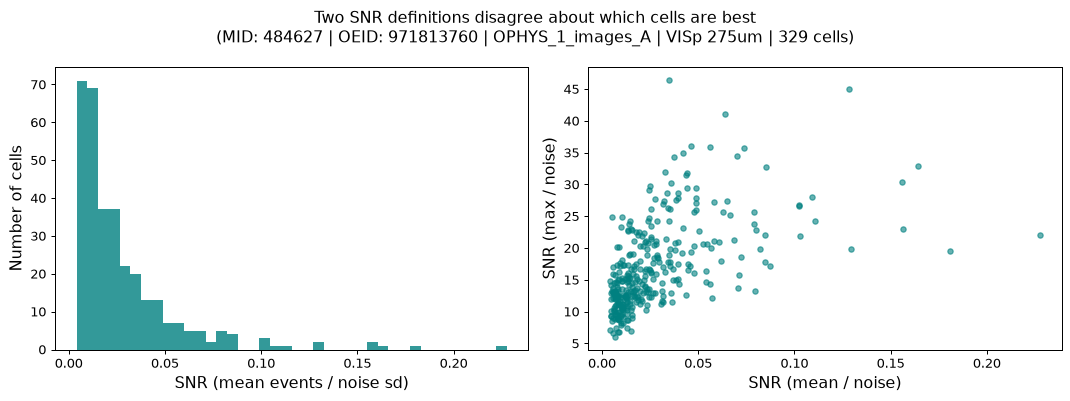

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].hist(snr_mean_over_noise, bins=40, color="teal", alpha=0.8)
ax[0].set_xlabel("SNR (mean events / noise sd)", fontsize=13)
ax[0].set_ylabel("Number of cells", fontsize=13)

ax[1].scatter(snr_mean_over_noise, snr_max_over_noise, s=18, color="teal", alpha=0.6)
ax[1].set_xlabel("SNR (mean / noise)", fontsize=13)
ax[1].set_ylabel("SNR (max / noise)", fontsize=13)

fig.suptitle(f"Two SNR definitions disagree about which cells are best\n({title_template})",
             fontsize=13)
fig.tight_layout()

# how much do the two definitions actually overlap in their top 10?
top10_mean = set(np.argsort(snr_mean_over_noise)[::-1][:10])
top10_max = set(np.argsort(snr_max_over_noise)[::-1][:10])
print("cells in the top 10 by BOTH definitions:", len(top10_mean & top10_max))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The two definitions share only a couple of cells in their top 10. This is a small but real
lesson: "the 10 best cells" is not a property of the data, it is a property of your selection
criterion. We proceed with mean/noise, and we will note where the choice shows up in the result.

</div>

In [25]:
N_CELLS = 10
top_cell_indices = np.argsort(snr_mean_over_noise)[::-1][:N_CELLS]
top_cell_specimen_ids = cell_specimen_table.index.values[top_cell_indices]

print("selected cell indices:      ", list(top_cell_indices))
print("selected cell_specimen_ids: ", list(top_cell_specimen_ids))
print("their SNR:                  ", np.round(snr_mean_over_noise[top_cell_indices], 2))

selected cell indices:       [np.int64(300), np.int64(292), np.int64(157), np.int64(284), np.int64(28), np.int64(23), np.int64(132), np.int64(253), np.int64(247), np.int64(321)]
selected cell_specimen_ids:  [np.int64(1080737612), np.int64(1080737526), np.int64(1080735371), np.int64(1080737452), np.int64(1080732812), np.int64(1080732727), np.int64(1080734991), np.int64(1080737063), np.int64(1080736883), np.int64(1080737982)]
their SNR:                   [0.23 0.18 0.16 0.16 0.16 0.13 0.13 0.11 0.11 0.1 ]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>2.2 Extracting discrete event times</h2>

Here is the key move for this section.

The events trace is a `(n_timepoints, n_cells)` array that is mostly zeros. We *could* treat it
as a continuous timeseries and average it, but that is not what we want here. Instead we treat
the nonzero timepoints as **event times**, exactly analogous to spike times from an
electrophysiology recording. That lets us reuse the classic raster / PSTH machinery you would
use for spikes.

For each cell: find the timepoints where the events trace is nonzero, and look up their
timestamps.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write a function that takes a cell index and returns the times at which that
cell had a detected event.

Hint: boolean-mask `ophys_timestamps` with `events_traces[:, cell_index] > 0`.

</div>

In [26]:
def get_event_times(cell_index):
    """Return the times of detected events for one cell, like a vector of spike times.

    Parameters
    ----------
    cell_index : int
        Column index into events_traces.

    Returns
    -------
    numpy.array of event times, in seconds, on the session clock.
    """
    has_event = events_traces[:, cell_index] > 0
    return ophys_timestamps[has_event]


def get_event_magnitudes(cell_index):
    """Return the magnitude of each detected event for one cell."""
    has_event = events_traces[:, cell_index] > 0
    return events_traces[has_event, cell_index]


# sanity check on our best cell
example_cell = top_cell_indices[0]
example_event_times = get_event_times(example_cell)

print("cell index:      ", example_cell)
print("number of events:", len(example_event_times))
print("event rate:       %.3f events/s" % (len(example_event_times) /
                                           (ophys_timestamps[-1] - ophys_timestamps[0])))
print("first 10 event times:", np.round(example_event_times[:10], 2))

cell index:       300
number of events: 1472
event rate:       0.327 events/s
first 10 event times: [ 9.34  9.43  9.62  9.71 10.08 10.27 10.55 16.05 16.51 16.89]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The alignment times</h3>

We align to **image changes** during the change detection block. Note that we take these from
the stimulus presentations table (`is_change`), not from the trials table. The two are closely
related but not identical: the trials table also contains aborted trials and catch trials, where
no image change actually occurred.

</div>

In [27]:
change_detection_stimuli = stimulus_presentations[
    stimulus_presentations.stimulus_block_name == "change_detection_behavior"
]

change_times = change_detection_stimuli[change_detection_stimuli.is_change].start_time.values

print("presentations in the task block:", len(change_detection_stimuli))
print("of which image changes:         ", len(change_times))
print("first few change times:         ", np.round(change_times[:5], 2))

presentations in the task block: 4799
of which image changes:          241
first few change times:          [321.01 330.77 354.06 386.34 410.35]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>2.3 Rasters and PSTHs</h2>

The standard construction, following the workshop's electrophysiology notebook:

- For each alignment time, take a window around it and keep only the events inside that window
- Subtract the alignment time, so 0 is the moment of the change
- Accumulate two vectors: the aligned event times, and which trial each event came from

The first vector plus the second gives you the raster (scatter of time vs trial). Histogramming
the first vector, dividing by the number of trials and by the bin width, gives you the PSTH in
events per second.

</div>

In [28]:
# --- the alignment window ---
PRE_WINDOW = 1.0    # how far before the change to look, in seconds
POST_WINDOW = 2.0   # how far after
BIN_SIZE = 0.1      # PSTH bin width, in seconds

psth_bins = np.arange(-PRE_WINDOW, POST_WINDOW + BIN_SIZE, BIN_SIZE)
psth_bin_centers = psth_bins[:-1] + BIN_SIZE / 2

print("window: %.1f to %.1f s in %d bins of %.0f ms"
      % (-PRE_WINDOW, POST_WINDOW, len(psth_bin_centers), BIN_SIZE * 1000))

window: -1.0 to 2.0 s in 30 bins of 100 ms


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write a function that aligns a vector of event times to a vector of
alignment times, and returns the aligned event times together with the trial index each event
came from.

</div>

In [29]:
def align_event_times(event_times, alignment_times, pre_window=PRE_WINDOW,
                      post_window=POST_WINDOW):
    """Align a vector of event times to a set of alignment times.

    Parameters
    ----------
    event_times : array
        Times of the events (our calcium events; spike times in an ephys dataset).
    alignment_times : array
        Times to align to (here, image change times).
    pre_window, post_window : float
        Window around each alignment time, in seconds.

    Returns
    -------
    aligned_times : array
        Event times relative to their alignment time. 0 = the aligned event.
    trial_index : array
        Which trial (index into alignment_times) each event came from.
    """
    aligned_times = []
    trial_index = []

    for i, alignment_time in enumerate(alignment_times):
        in_window = ((event_times >= alignment_time - pre_window)
                     & (event_times < alignment_time + post_window))
        trial_event_times = event_times[in_window] - alignment_time

        aligned_times.append(trial_event_times)
        trial_index.append(np.full(len(trial_event_times), i))

    return np.concatenate(aligned_times), np.concatenate(trial_index)


def compute_psth(aligned_times, n_trials, bins=psth_bins, bin_size=BIN_SIZE):
    """Histogram aligned event times into a PSTH in events per second."""
    counts, _ = np.histogram(aligned_times, bins=bins)
    return counts / n_trials / bin_size


# check it on one cell
aligned_times, trial_index = align_event_times(example_event_times, change_times)
print("events falling in the window across all %d trials: %d" % (len(change_times),
                                                                 len(aligned_times)))
print("trials with at least one event: %d" % len(np.unique(trial_index)))

events falling in the window across all 241 trials: 178
trials with at least one event: 71


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the raster and PSTH for the 10 selected cells, one column per cell.
Put the raster on the top row and the PSTH on the bottom row, and mark the change time.

</div>

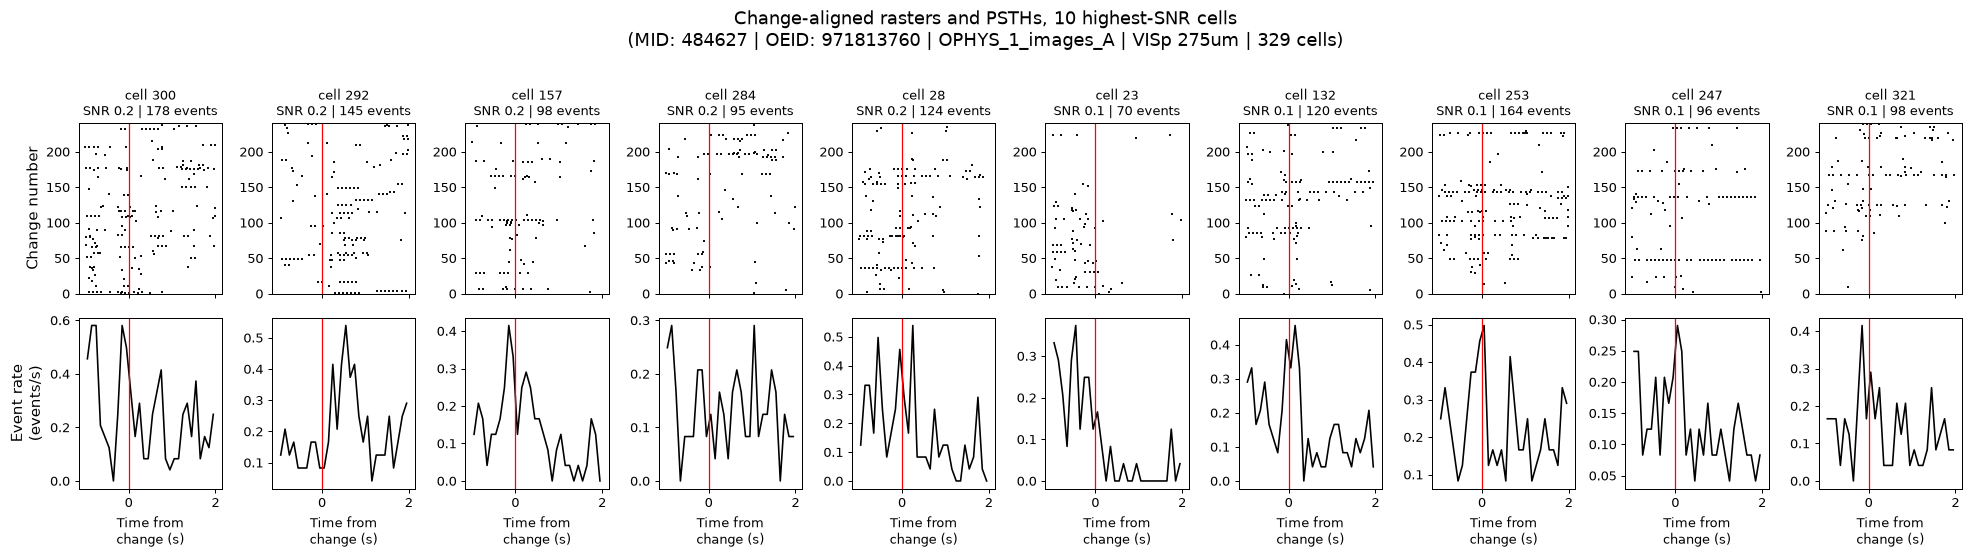

In [30]:
fig, ax = plt.subplots(2, N_CELLS, figsize=(22, 6), sharex=True)

for column, cell_index in enumerate(top_cell_indices):
    event_times = get_event_times(cell_index)
    aligned_times, trial_index = align_event_times(event_times, change_times)
    psth = compute_psth(aligned_times, n_trials=len(change_times))

    # --- raster ---
    ax[0, column].scatter(aligned_times, trial_index, s=2, color="black", marker="|")
    ax[0, column].axvline(0, color="red", lw=1)
    ax[0, column].set_ylim(0, len(change_times))
    ax[0, column].set_title("cell %d\nSNR %.1f | %d events"
                            % (cell_index, snr_mean_over_noise[cell_index], len(aligned_times)),
                            fontsize=10)

    # --- PSTH ---
    ax[1, column].plot(psth_bin_centers, psth, color="black", lw=1.3)
    ax[1, column].axvline(0, color="red", lw=1)
    ax[1, column].set_xlabel("Time from\nchange (s)", fontsize=10)

    if column == 0:
        ax[0, column].set_ylabel("Change number", fontsize=12)
        ax[1, column].set_ylabel("Event rate\n(events/s)", fontsize=12)

fig.suptitle(f"Change-aligned rasters and PSTHs, 10 highest-SNR cells\n({title_template})",
             fontsize=14, y=1.02)
fig.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

This figure is the point of the section. Read it two ways.

**Down a column (across trials).** Even for the best cells in the recording, the raster is
sparse and irregular. Most trials have zero or one event in the whole three-second window. No
individual trial looks like the PSTH. This is what trial-to-trial variability looks like at the
level of single cells &mdash; and calcium event detection makes it starker, because events are
sparse by construction.

**Across columns (across neurons).** These 10 cells were all selected by the same criterion, and
they still do not behave alike. Some show a clear post-change increase; others are flat; at
least one is *more* active before the change than after. "Excitatory cells in VISp" is not a
functional description.

The average hides all of this, which is why you look at the raster first.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Quantify the change modulation for each of the 10 cells: compare the event
rate in the 0 to 0.75&nbsp;s window after the change to the rate in the 1&nbsp;s before it.

Compute a modulation index, `(post - pre) / (post + pre)`, and plot it. How many of the 10 cells
are actually driven by the change?

</div>

 cell_index  pre_rate  post_rate  modulation_index
        300    0.3444     0.2213           -0.2176
        292    0.1286     0.3154            0.4206
        157    0.1950     0.1881           -0.0181
        284    0.1452     0.1272           -0.0660
         28    0.2656     0.1936           -0.1566
         23    0.2324     0.0498           -0.6471
        132    0.2282     0.1826           -0.1111
        253    0.2656     0.2379           -0.0549
        247    0.1701     0.1438           -0.0837
        321    0.1618     0.1438           -0.0588

cells positively modulated by the change: 1 / 10


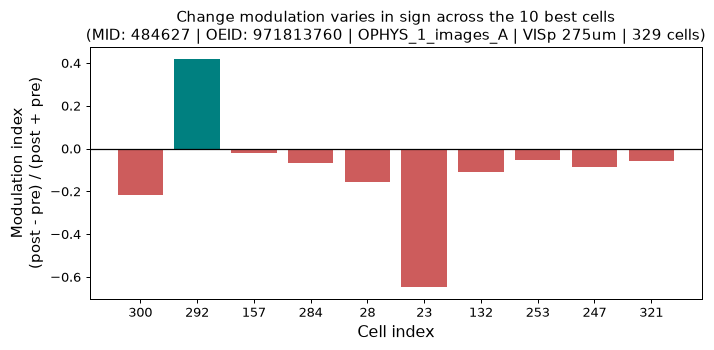

In [31]:
modulation = []
for cell_index in top_cell_indices:
    aligned_times, _ = align_event_times(get_event_times(cell_index), change_times)

    post_rate = np.sum((aligned_times >= 0) & (aligned_times < 0.75)) / 0.75
    pre_rate = np.sum((aligned_times >= -1) & (aligned_times < 0)) / 1.0

    modulation.append({
        "cell_index": cell_index,
        "pre_rate": pre_rate / len(change_times),
        "post_rate": post_rate / len(change_times),
        "modulation_index": (post_rate - pre_rate) / (post_rate + pre_rate)
        if (post_rate + pre_rate) > 0 else np.nan,
    })

modulation = pd.DataFrame(modulation)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["teal" if m > 0 else "indianred" for m in modulation.modulation_index]
ax.bar(range(len(modulation)), modulation.modulation_index, color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(len(modulation)))
ax.set_xticklabels(modulation.cell_index, fontsize=10)
ax.set_xlabel("Cell index", fontsize=13)
ax.set_ylabel("Modulation index\n(post - pre) / (post + pre)", fontsize=12)
ax.set_title(f"Change modulation varies in sign across the 10 best cells\n({title_template})",
             fontsize=12)
fig.tight_layout()

print(modulation.round(4).to_string(index=False))
print()
print("cells positively modulated by the change: %d / %d"
      % (int((modulation.modulation_index > 0).sum()), len(modulation)))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The population PSTH</h3>

For contrast, here is what happens when you average across all 329 cells instead of looking at
10. The change response is obvious &mdash; because averaging over cells and trials is exactly what
kills the variability we just spent a figure looking at.

</div>

peak of the population response at 0.25 s after the change


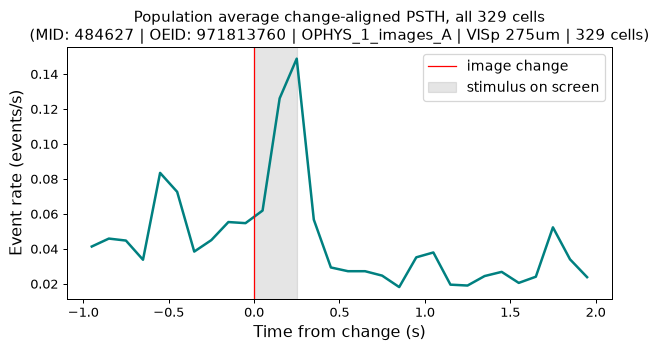

In [32]:
population_psth = np.zeros(len(psth_bin_centers))

for cell_index in range(events_traces.shape[1]):
    aligned_times, _ = align_event_times(get_event_times(cell_index), change_times)
    population_psth += compute_psth(aligned_times, n_trials=len(change_times))

population_psth /= events_traces.shape[1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(psth_bin_centers, population_psth, color="teal", lw=2)
ax.axvline(0, color="red", lw=1, label="image change")
ax.axvspan(0, 0.25, color="gray", alpha=0.2, zorder=0, label="stimulus on screen")
ax.set_xlabel("Time from change (s)", fontsize=13)
ax.set_ylabel("Event rate (events/s)", fontsize=13)
ax.legend(fontsize=11)
ax.set_title(f"Population average change-aligned PSTH, all {events_traces.shape[1]} cells\n"
             f"({title_template})", fontsize=12)
fig.tight_layout()

peak_bin = np.argmax(population_psth)
print("peak of the population response at %.2f s after the change" % psth_bin_centers[peak_bin])

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>2.4 The same alignment a second way: dF/F and <code>event_triggered_response</code></h2>

Everything above treated the events as discrete times. Now we do the same alignment on the
**continuous dF/F** traces, and we use a library function instead of writing the loop ourselves:
`brain_observatory_utilities.utilities.general_utilities.event_triggered_response`.

Why it is worth knowing about: our hand-written `align_event_times` works because event times
are just numbers we can subtract. Aligning a *continuous* trace is harder, because the ophys
timestamps do not line up with the stimulus times &mdash; each change falls somewhere between two
imaging frames. `event_triggered_response` handles this by **linearly interpolating** each slice
onto a common timebase, so all trials are directly comparable.

It expects a *tidy* dataframe: one row per observation, with a time column and a value column.

</div>

In [33]:
# build a tidy dataframe for one cell: one row per timepoint
example_cell_specimen_id = top_cell_specimen_ids[0]

tidy_cell = pd.DataFrame({
    "timestamps": ophys_timestamps,
    "dff": dff_traces[:, top_cell_indices[0]],
})

etr = event_triggered_response(
    data=tidy_cell,
    t="timestamps",
    y="dff",
    event_times=change_times,
    t_before=PRE_WINDOW,
    t_after=POST_WINDOW,
    output_sampling_rate=30,     # interpolate up to a common 30 Hz timebase
    output_format="tidy",
)

print("tidy output:", etr.shape)
print("columns:", list(etr.columns))
etr.head()

tidy output: (21931, 5)
columns: ['time', 'dff', 'event_number', 'original_index', 'event_time']


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The tidy output has one row per (trial, timepoint), with columns for `time` (relative to
the event), the value, and `event_number` / `event_time` identifying the trial. That format plugs
straight into seaborn, which will compute the mean and a bootstrapped confidence interval for
you.

</div>

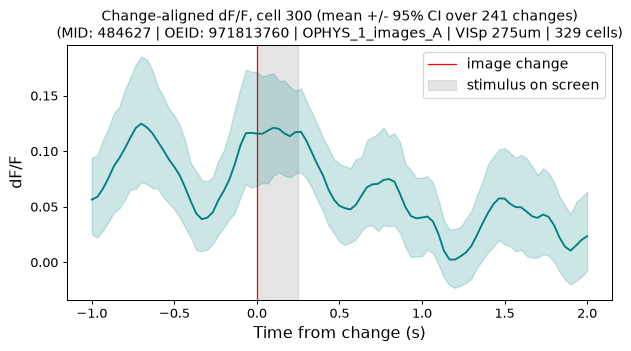

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.lineplot(data=etr, x="time", y="dff", ax=ax, color="teal", errorbar=("ci", 95))
ax.axvline(0, color="red", lw=1, label="image change")
ax.axvspan(0, 0.25, color="gray", alpha=0.2, zorder=0, label="stimulus on screen")
ax.set_xlabel("Time from change (s)", fontsize=13)
ax.set_ylabel("dF/F", fontsize=13)
ax.legend(fontsize=11)
ax.set_title(f"Change-aligned dF/F, cell {top_cell_indices[0]} (mean +/- 95% CI over "
             f"{len(change_times)} changes)\n({title_template})", fontsize=11)
fig.tight_layout()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Use `event_triggered_response` to get the change-aligned dF/F for all 10
selected cells, and plot them in a grid like the raster figure. Include the single-trial traces
behind the mean so the trial-to-trial variability stays visible.

How does the dF/F picture compare to the events picture for the same cells?

</div>

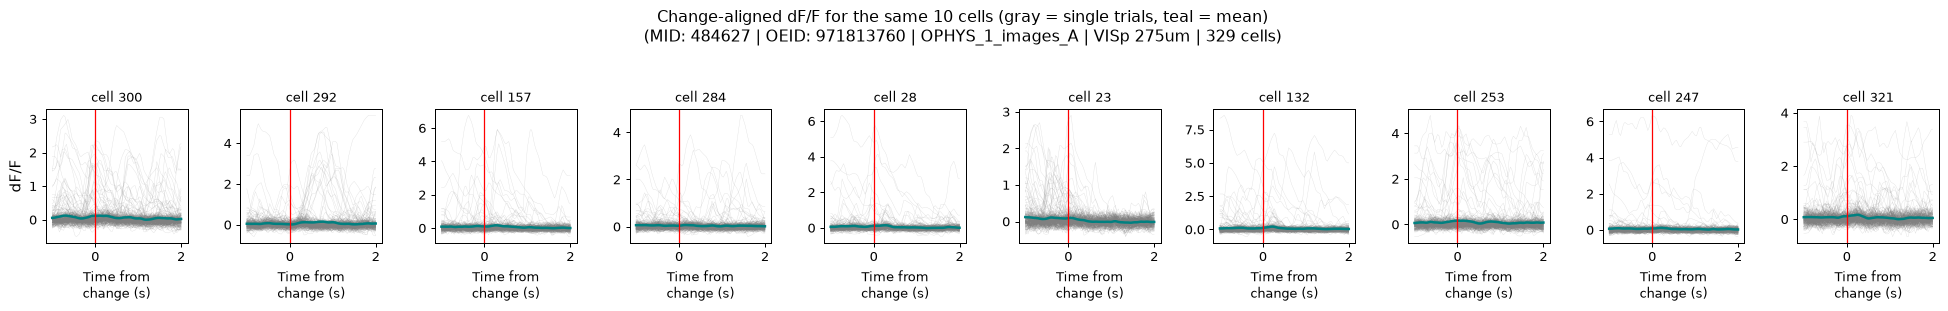

In [35]:
fig, ax = plt.subplots(1, N_CELLS, figsize=(22, 3.2), sharex=True)

etr_by_cell = {}

for column, cell_index in enumerate(top_cell_indices):
    tidy_cell = pd.DataFrame({
        "timestamps": ophys_timestamps,
        "dff": dff_traces[:, cell_index],
    })

    etr_wide = event_triggered_response(
        data=tidy_cell,
        t="timestamps",
        y="dff",
        event_times=change_times,
        t_before=PRE_WINDOW,
        t_after=POST_WINDOW,
        output_sampling_rate=30,
        output_format="wide",     # timepoints as index, one column per trial
    )
    etr_by_cell[cell_index] = etr_wide

    trace_times = etr_wide.index.values

    # individual trials, faint
    ax[column].plot(trace_times, etr_wide.values, color="gray", lw=0.3, alpha=0.25)
    # the mean across trials
    ax[column].plot(trace_times, etr_wide.values.mean(axis=1), color="teal", lw=2)

    ax[column].axvline(0, color="red", lw=1)
    ax[column].set_title(f"cell {cell_index}", fontsize=10)
    ax[column].set_xlabel("Time from\nchange (s)", fontsize=10)

ax[0].set_ylabel("dF/F", fontsize=12)

fig.suptitle("Change-aligned dF/F for the same 10 cells (gray = single trials, teal = mean)\n"
             f"({title_template})", fontsize=13, y=1.06)
fig.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Compare this to the raster figure. The dF/F means look far smoother and more
"response-like" &mdash; but that is partly an artifact of the measurement. Calcium fluorescence
decays over hundreds of milliseconds, so dF/F low-pass filters the underlying activity and
neighbouring trials bleed into each other. The single-trial traces in gray are the honest
picture: still highly variable, just variable in a smoother way.

The events representation is sparser and harder to look at, but it is closer to the spiking. Use
dF/F when you care about the shape of the response and events when you care about *when*
activity happened. Neither is "the data".

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise (extension):** Split the change-aligned dF/F by trial outcome &mdash; hits versus
misses &mdash; for one cell. Does the neural response to the change differ depending on whether
the mouse reported it?

Hint: `change_detection_stimuli` has a `trials_id` column you can use to join to the `trials`
table and get the outcome for each change.

</div>

hit changes: 128 | miss changes: 108


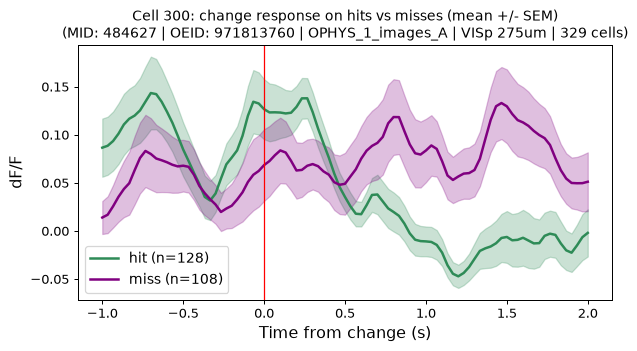

In [36]:
# join each change presentation to its trial outcome
changes_with_outcome = change_detection_stimuli[change_detection_stimuli.is_change].merge(
    trials[["hit", "miss"]], left_on="trials_id", right_index=True, how="left"
)

hit_change_times = changes_with_outcome[changes_with_outcome.hit].start_time.values
miss_change_times = changes_with_outcome[changes_with_outcome.miss].start_time.values

print("hit changes: %d | miss changes: %d" % (len(hit_change_times), len(miss_change_times)))

cell_index = top_cell_indices[0]
tidy_cell = pd.DataFrame({"timestamps": ophys_timestamps, "dff": dff_traces[:, cell_index]})

fig, ax = plt.subplots(figsize=(7, 4))

for outcome_times, label, color in [(hit_change_times, "hit", "seagreen"),
                                    (miss_change_times, "miss", "purple")]:
    etr_outcome = event_triggered_response(
        data=tidy_cell, t="timestamps", y="dff", event_times=outcome_times,
        t_before=PRE_WINDOW, t_after=POST_WINDOW,
        output_sampling_rate=30, output_format="wide")

    mean_trace = etr_outcome.values.mean(axis=1)
    sem_trace = etr_outcome.values.std(axis=1) / np.sqrt(etr_outcome.shape[1])
    trace_times = etr_outcome.index.values

    ax.plot(trace_times, mean_trace, color=color, lw=2, label=f"{label} (n={etr_outcome.shape[1]})")
    ax.fill_between(trace_times, mean_trace - sem_trace, mean_trace + sem_trace,
                    color=color, alpha=0.25)

ax.axvline(0, color="red", lw=1)
ax.set_xlabel("Time from change (s)", fontsize=13)
ax.set_ylabel("dF/F", fontsize=13)
ax.legend(fontsize=11)
ax.set_title(f"Cell {cell_index}: change response on hits vs misses (mean +/- SEM)\n"
             f"({title_template})", fontsize=11)
fig.tight_layout()

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Question 3: Correlations across neurons, compared between conditions</h1>

So far we have treated cells one at a time. But the interesting structure in a population is
often in how cells covary: neurons that are correlated may be connected, or may share a common
input, or may belong to the same functional subnetwork.

The question then becomes: **does that correlation structure depend on condition?**

This session gives us a clean way to ask. Recall the block structure from Question 1: five
minutes of gray screen, then the task, then five more minutes of gray screen. The two gray screen
blocks have **identical sensory input** (none) and **no task demands** &mdash; but one comes before
an hour of change detection and one comes after.

In this section you will:

1. Compute pairwise correlations of dF/F in the two spontaneous windows and compare them
2. Then, as an extension, use `get_stimulus_response_df` to ask a subtler question: is the
   population structure in the moment **just before** a change different on hits versus misses?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>3.1 The two spontaneous windows</h2>

We already have the block boundaries in `block_table`. Pull the dF/F for the two gray screen
blocks.

Note the orientation: `dff_traces` is `(timepoints, cells)`, but `np.corrcoef` treats **rows** as
variables. So we transpose to `(cells, timepoints)` before correlating &mdash; otherwise you get a
timepoint-by-timepoint correlation matrix, which is a real thing but not what we want.

</div>

In [37]:
spontaneous_blocks = ["initial_gray_screen_5min", "post_behavior_gray_screen_5min"]

spontaneous_dff = {}
for block_name in spontaneous_blocks:
    row = block_table.loc[block_name]
    in_block = (ophys_timestamps >= row.start_time) & (ophys_timestamps < row.stop_time)
    # transpose to (cells, timepoints) -- np.corrcoef correlates rows
    spontaneous_dff[block_name] = dff_traces[in_block, :].T

    print("%-32s %s   %.1f s" % (block_name, spontaneous_dff[block_name].shape,
                                 row.stop_time - row.start_time))

dff_pre = spontaneous_dff["initial_gray_screen_5min"]
dff_post = spontaneous_dff["post_behavior_gray_screen_5min"]

initial_gray_screen_5min         (329, 3219)   309.0 s
post_behavior_gray_screen_5min   (329, 3223)   300.5 s


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Visualize the dF/F for each spontaneous period as a heatmap, cells on one
axis and time on the other. Label your axes.

Hint: `pcolormesh` makes nicer heatmaps than `imshow` and handles the axes sensibly, though it
is a bit slower.

</div>

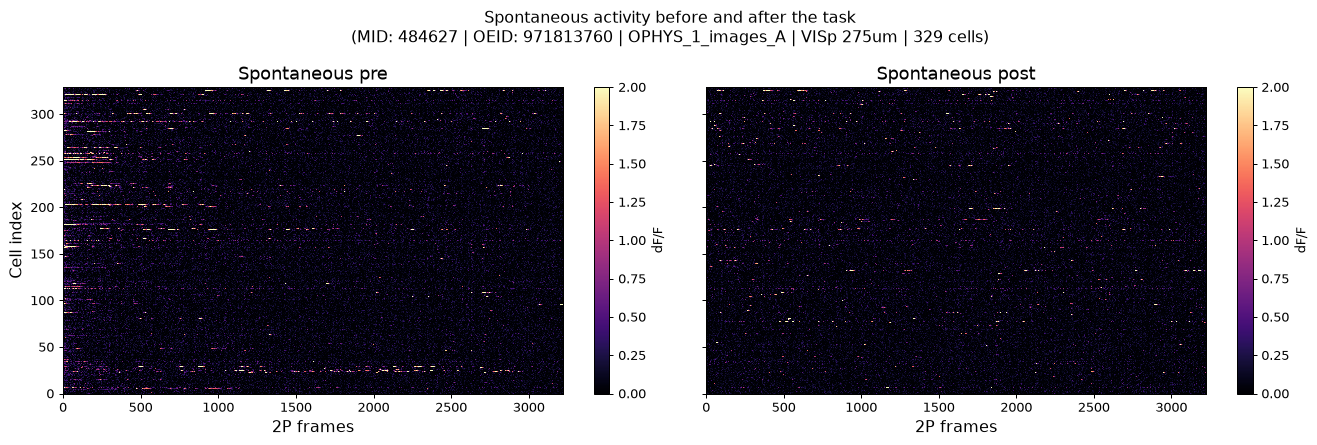

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for panel, (data, label) in enumerate([(dff_pre, "Spontaneous pre"),
                                       (dff_post, "Spontaneous post")]):
    mesh = ax[panel].pcolormesh(data, vmin=0, vmax=2, cmap="magma")
    ax[panel].set_xlabel("2P frames", fontsize=13)
    ax[panel].set_title(label, fontsize=14)
    fig.colorbar(mesh, ax=ax[panel], label="dF/F")

ax[0].set_ylabel("Cell index", fontsize=13)
fig.suptitle(f"Spontaneous activity before and after the task\n({title_template})", fontsize=13)
fig.tight_layout()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the pairwise correlation between every cell pair's dF/F trace, for
the pre and post spontaneous periods, using `np.corrcoef`.

Save them to `correlations_pre` and `correlations_post`; we use them again below.

</div>

In [39]:
correlations_pre = np.corrcoef(dff_pre)
correlations_post = np.corrcoef(dff_post)

print("correlation matrix shape:", correlations_pre.shape)
print("(n_cells x n_cells)")

correlation matrix shape: (329, 329)
(n_cells x n_cells)


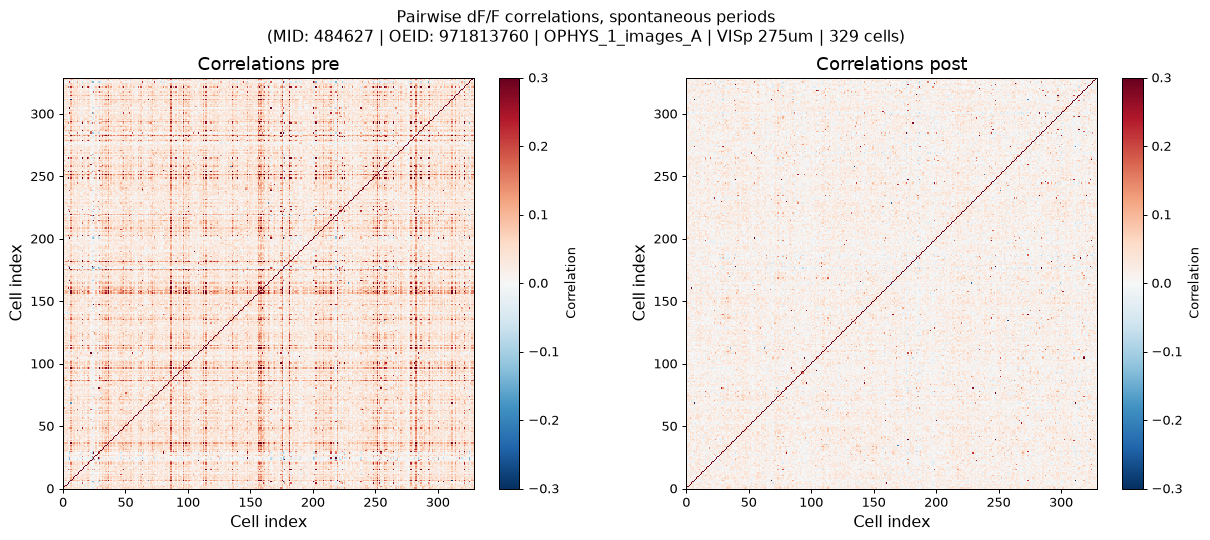

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

for panel, (matrix, label) in enumerate([(correlations_pre, "Correlations pre"),
                                         (correlations_post, "Correlations post")]):
    mesh = ax[panel].pcolormesh(matrix, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    ax[panel].set_xlabel("Cell index", fontsize=13)
    ax[panel].set_ylabel("Cell index", fontsize=13)
    ax[panel].set_title(label, fontsize=14)
    ax[panel].axis("square")
    fig.colorbar(mesh, ax=ax[panel], label="Correlation", fraction=0.046)

fig.suptitle(f"Pairwise dF/F correlations, spontaneous periods\n({title_template})", fontsize=13)
fig.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Getting the unique pairs</h3>

To compare the *distributions* of correlation values we need to be careful about what goes into
them. A full correlation matrix contains each pair twice (it is symmetric) and has ones down the
diagonal (every cell's correlation with itself).

Including those would bias the mean and inflate the sample size. `np.triu_indices` with `k=1`
gives us the indices of the upper triangle **excluding** the diagonal &mdash; each pair exactly
once.

(A note on a common trap: `np.triu(matrix, k=1)` *zeros out* the lower triangle rather than
removing it. If you then flatten and histogram the result, you get a huge artificial spike at
zero from all the entries you zeroed. Indexing with `triu_indices` avoids this.)

</div>

In [41]:
upper_triangle = np.triu_indices(correlations_pre.shape[0], k=1)

correlations_pre_flat = correlations_pre[upper_triangle]
correlations_post_flat = correlations_post[upper_triangle]

n_cells = correlations_pre.shape[0]
print("cells:                %d" % n_cells)
print("unique cell pairs:    %d   (= n*(n-1)/2 = %d)"
      % (len(correlations_pre_flat), n_cells * (n_cells - 1) // 2))
print()
print("mean correlation pre:  %.4f" % np.nanmean(correlations_pre_flat))
print("mean correlation post: %.4f" % np.nanmean(correlations_post_flat))

cells:                329
unique cell pairs:    53956   (= n*(n-1)/2 = 53956)

mean correlation pre:  0.0421
mean correlation post: 0.0149


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Test whether the distribution of pairwise correlations differs between the
two spontaneous periods, and plot both distributions with the p-value in the title.

Then think hard about the statistics. Is a t-test on cell pairs the right test here?

</div>

t = 115.93, p = 0.000e+00


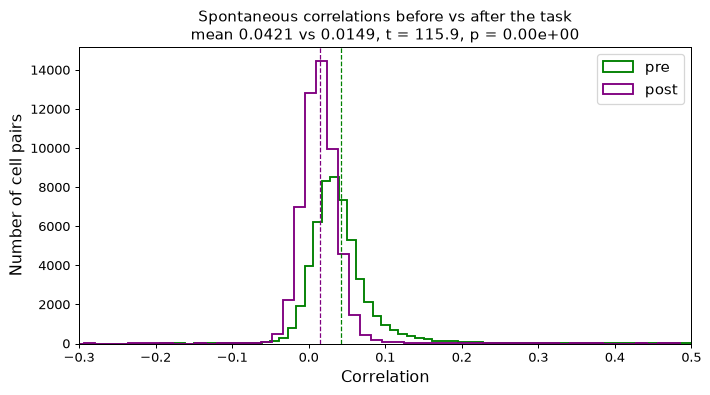

In [42]:
t_statistic, p_value = stats.ttest_ind(correlations_pre_flat, correlations_post_flat,
                                       nan_policy="omit")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(correlations_pre_flat, bins=100, color="green", label="pre", histtype="step", lw=1.5)
ax.hist(correlations_post_flat, bins=100, color="purple", label="post", histtype="step", lw=1.5)
ax.axvline(np.nanmean(correlations_pre_flat), color="green", ls="--", lw=1)
ax.axvline(np.nanmean(correlations_post_flat), color="purple", ls="--", lw=1)

ax.set_xlabel("Correlation", fontsize=13)
ax.set_ylabel("Number of cell pairs", fontsize=13)
ax.set_xlim(-0.3, 0.5)
ax.legend(fontsize=12)
ax.set_title("Spontaneous correlations before vs after the task\n"
             "mean %.4f vs %.4f, t = %.1f, p = %.2e"
             % (np.nanmean(correlations_pre_flat), np.nanmean(correlations_post_flat),
                t_statistic, p_value), fontsize=12)
fig.tight_layout()

print("t = %.2f, p = %.3e" % (t_statistic, p_value))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What that p-value does and does not mean</h3>

The distributions clearly differ, and the t-test returns an astronomically small p-value. Be
careful about how much you make of that.

The test treats each of the ~54,000 cell pairs as an independent observation. **They are not
independent** &mdash; they are 54,000 pairwise combinations of only 329 cells, so every cell appears
in 328 of them. With an n that inflated, any difference at all will come out "significant". The
p-value here is really telling you about the size of your matrix, not the strength of your
evidence.

The **effect size** is the honest number: the mean pairwise correlation is roughly three times
higher before the task than after. That is a substantial difference in population structure, and
it is what you would report.

If you wanted a defensible statistical test you would need to respect the dependency structure
&mdash; for instance by bootstrapping over *cells* rather than pairs, or by comparing to a null
built from time-shifted traces. This is a good thing to be suspicious about in published work
too.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise (interpretation):** Give two possible explanations for a decrease in spontaneous
correlations after the task, and for each one suggest something in this dataset you could check.

*Answer:*
1. **Arousal or behavioral state.** The mouse may be more alert at the start of the session and
   drowsy at the end, and global state changes drive shared variability across the population.
   *Check:* compare running speed and pupil diameter (`/acquisition/EyeTracking`) between the two
   gray screen blocks. If arousal differs, that is the parsimonious explanation.
2. **Adaptation or plasticity from the task itself.** An hour of change detection could reshape
   functional coupling in the population.
   *Check:* the two gray screen blocks are separated by an hour, so time and task are confounded
   in this session. To separate them you would need a passive session with the same block
   structure and no task, which the dataset contains &mdash; the `OPHYS_2_images_A_passive`
   session for this same container.

Note that these two explanations are not distinguishable from this figure alone, which is the
point of the exercise.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise (extension):** Do correlations depend on the physical distance between cells?
The `cell_specimen_table` has `x` and `y` positions in the field of view.

</div>

Spearman correlation of distance with pairwise correlation:
  pre:  rho = -0.067, p = 9.19e-55
  post: rho = -0.149, p = 3.27e-266


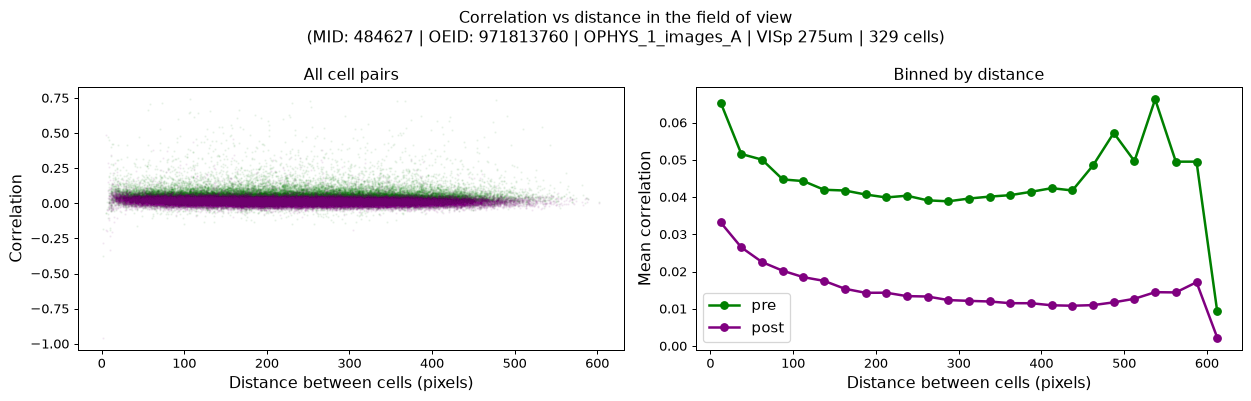

In [43]:
cell_x = cell_specimen_table["x"].values
cell_y = cell_specimen_table["y"].values

# pairwise distance for the same upper-triangle pairs we used above
pair_distance = np.sqrt((cell_x[upper_triangle[0]] - cell_x[upper_triangle[1]]) ** 2
                        + (cell_y[upper_triangle[0]] - cell_y[upper_triangle[1]]) ** 2)

pairs = pd.DataFrame({
    "cell_index_1": upper_triangle[0],
    "cell_index_2": upper_triangle[1],
    "distance_px": pair_distance,
    "correlation_pre": correlations_pre_flat,
    "correlation_post": correlations_post_flat,
})
pairs["correlation_difference"] = pairs.correlation_post - pairs.correlation_pre

# bin by distance so the trend is visible through 54k points
distance_bins = np.arange(0, pairs.distance_px.max() + 25, 25)
pairs["distance_bin"] = pd.cut(pairs.distance_px, distance_bins,
                               labels=distance_bins[:-1] + 12.5)
binned = pairs.groupby("distance_bin", observed=True)[["correlation_pre", "correlation_post"]].mean()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].plot(pairs.distance_px, pairs.correlation_pre, ".", color="green", alpha=0.05, ms=2)
ax[0].plot(pairs.distance_px, pairs.correlation_post, ".", color="purple", alpha=0.05, ms=2)
ax[0].set_ylabel("Correlation", fontsize=13)
ax[0].set_title("All cell pairs", fontsize=13)

ax[1].plot(binned.index.astype(float), binned.correlation_pre, "-o", color="green",
           label="pre", lw=2)
ax[1].plot(binned.index.astype(float), binned.correlation_post, "-o", color="purple",
           label="post", lw=2)
ax[1].set_ylabel("Mean correlation", fontsize=13)
ax[1].set_title("Binned by distance", fontsize=13)
ax[1].legend(fontsize=12)

for panel in ax:
    panel.set_xlabel("Distance between cells (pixels)", fontsize=13)

fig.suptitle(f"Correlation vs distance in the field of view\n({title_template})", fontsize=13)
fig.tight_layout()

print("Spearman correlation of distance with pairwise correlation:")
print("  pre:  rho = %.3f, p = %.2e" % stats.spearmanr(pairs.distance_px, pairs.correlation_pre))
print("  post: rho = %.3f, p = %.2e" % stats.spearmanr(pairs.distance_px, pairs.correlation_post))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>3.2 Extension: population structure just before hits versus misses</h2>

The spontaneous comparison used long, quiet windows. Now a subtler version of the same question.

On some trials the mouse detects the change (**hit**); on others it does not (**miss**). Both are
`go` trials with a real image change, so the stimulus is matched. If the population state in the
moment *before* the change differs between the two, that is a candidate neural correlate of
whatever determined the outcome &mdash; attention, arousal, engagement.

To ask this we need the mean activity in a **pre-stimulus baseline window** for every cell on
every trial. That is exactly what
`brain_observatory_utilities.datasets.optical_physiology.data_formatting.get_stimulus_response_df`
computes: it aligns every cell to every stimulus presentation and returns, per (cell, trial), the
mean response after onset and the mean baseline before it.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Making our NWB data look like an AllenSDK object</h3>

`get_stimulus_response_df` was written to take an AllenSDK `BehaviorOphysExperiment`. We
deliberately have not used the AllenSDK &mdash; so we build a small class that exposes the same
handful of attributes the function actually reaches for, backed by the arrays we read out of the
NWB file ourselves.

This "duck typing" pattern is worth having in your toolkit. When a library wants an object you
do not have, you often do not need the real thing &mdash; only the attributes it touches. Reading
the source to find out which ones those are takes ten minutes and saves you a dependency.

The attributes needed here: `ophys_timestamps`, `dff_traces`, `events`, `cell_specimen_table`,
`stimulus_presentations`, `running_speed`, `metadata`, `trials`.

</div>

In [44]:
class NWBOphysExperiment:
    """Minimal stand-in for an AllenSDK BehaviorOphysExperiment, built from an NWB file.

    Exposes only the attributes that brain_observatory_utilities actually accesses.
    """

    def __init__(self, nwb_path):
        with h5py.File(nwb_path, "r") as nwb:
            self.ophys_timestamps = nwb["/processing/ophys/dff/traces/timestamps"][:]
            dff = nwb["/processing/ophys/dff/traces/data"][:]
            events = nwb["/processing/ophys/event_detection/data"][:]

            self.metadata = dict(nwb["/general/metadata"].attrs)
            self.trials = read_nwb_table(nwb, "/intervals/trials")

            cell_table = read_nwb_table(
                nwb, "/processing/ophys/image_segmentation/cell_specimen_table")

            presentation_keys = [k for k in nwb["/intervals"].keys()
                                 if k.endswith("_presentations")]
            stimuli = pd.concat([read_nwb_table(nwb, f"/intervals/{k}")
                                 for k in presentation_keys]).sort_values("start_time")

            self.running_speed = pd.DataFrame({
                "timestamps": nwb["/processing/running/speed/timestamps"][:],
                "speed": nwb["/processing/running/speed/data"][:],
            })

        # --- stimulus_presentations, indexed the way the SDK indexes it ---
        stimuli = stimuli.reset_index(drop=True)
        stimuli.index.name = "stimulus_presentations_id"
        for column in ["is_change", "omitted", "is_image_novel"]:
            if column in stimuli.columns:
                stimuli[column] = stimuli[column].fillna(0).astype(bool)
        self.stimulus_presentations = stimuli

        # --- cell_specimen_table, indexed by cell_specimen_id ---
        cell_table = cell_table.reset_index().rename(columns={"id": "cell_roi_id"})
        if "cell_roi_id" not in cell_table.columns:
            cell_table["cell_roi_id"] = np.arange(len(cell_table))
        self.cell_specimen_table = cell_table.set_index("cell_specimen_id")

        cell_specimen_ids = self.cell_specimen_table.index.values

        # --- dff_traces and events: one row per cell, the trace held as an array ---
        self.dff_traces = pd.DataFrame(
            {"dff": [dff[:, i] for i in range(dff.shape[1])],
             "cell_roi_id": self.cell_specimen_table.cell_roi_id.values},
            index=cell_specimen_ids)
        self.dff_traces.index.name = "cell_specimen_id"

        self.events = pd.DataFrame(
            {"events": [events[:, i] for i in range(events.shape[1])],
             "filtered_events": [gaussian_filter1d(events[:, i], 2)
                                 for i in range(events.shape[1])]},
            index=cell_specimen_ids)
        self.events.index.name = "cell_specimen_id"


ophys_experiment = NWBOphysExperiment(nwb_path)

print("stimulus_presentations:", ophys_experiment.stimulus_presentations.shape)
print("dff_traces:            ", ophys_experiment.dff_traces.shape)
print("cell_specimen_table:   ", ophys_experiment.cell_specimen_table.shape)
print("trials:                ", ophys_experiment.trials.shape)

stimulus_presentations: (13801, 20)
dff_traces:             (329, 2)
cell_specimen_table:    (329, 11)
trials:                 (604, 21)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Getting the stimulus-aligned responses</h3>

`get_stimulus_response_df` internally limits itself to the change detection block, so we get the
task presentations only. A few parameters worth understanding:

- `data_type="dff"` &mdash; which signal to align
- `event_type="all"` &mdash; align to every stimulus presentation, not only changes
- `time_window=[-1, 1]` &mdash; how much trace to keep around each onset
- `response_window_duration=0.5` &mdash; the window used for the mean response (0 to +0.5&nbsp;s)
  and, symmetrically, the baseline (-0.5 to 0&nbsp;s)

**This cell takes a couple of minutes** &mdash; it interpolates every cell against every
presentation, which is 329 cells x ~4800 presentations.

One naming note: the prompt for this exercise refers to a `mean_baseline` column. In this version
of the package the dataframe returns it as **`baseline_response`** (the name `mean_baseline` is
used internally, in the intermediate xarray). Same quantity, different label &mdash; a good reminder
to check the columns you actually got rather than the ones you expected.

</div>

In [45]:
stimulus_response_df = ophys_formatting.get_stimulus_response_df(
    ophys_experiment,
    data_type="dff",
    event_type="all",
    time_window=[-1, 1],
    response_window_duration=0.5,
    output_sampling_rate=10,
)

print("stimulus_response_df:", stimulus_response_df.shape)
print()
print("columns:")
for column in stimulus_response_df.columns:
    print("  ", column)

stimulus_response_df: (1578871, 13)

columns:
   stimulus_presentations_id
   cell_specimen_id
   trace
   trace_timestamps
   mean_response
   baseline_response
   p_value_gray_screen
   ophys_frame_rate
   data_type
   event_type
   interpolate
   output_sampling_rate
   response_window_duration


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Merge `stimulus_response_df` with the `stimulus_presentations` table so each
row knows whether it was a change, and then with the `trials` table so it knows the trial
outcome.

</div>

In [46]:
stimulus_metadata_columns = ["start_time", "is_change", "omitted", "image_name",
                             "trials_id", "stimulus_block_name"]

response_df = stimulus_response_df.merge(
    ophys_experiment.stimulus_presentations[stimulus_metadata_columns],
    left_on="stimulus_presentations_id", right_index=True, how="left")

trial_outcome_columns = ["hit", "miss", "false_alarm", "correct_reject", "aborted", "auto_rewarded"]

response_df = response_df.merge(
    ophys_experiment.trials[trial_outcome_columns],
    left_on="trials_id", right_index=True, how="left")

print("merged:", response_df.shape)

change_responses = response_df[response_df.is_change]

print()
print("change presentations:", change_responses.stimulus_presentations_id.nunique())
print("  hits:              ", change_responses[change_responses.hit].stimulus_presentations_id.nunique())
print("  misses:            ", change_responses[change_responses.miss].stimulus_presentations_id.nunique())
print("cells:               ", change_responses.cell_specimen_id.nunique())

change_responses[["stimulus_presentations_id", "cell_specimen_id", "mean_response",
                  "baseline_response", "is_change", "hit", "miss"]].head()

merged: (1578871, 25)

change presentations: 241
  hits:               128
  misses:             108
cells:                329


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** For hit trials, build a cells x trials matrix of `baseline_response` and
compute the correlation between every pair of cells. Do the same for miss trials. Compare.

This is a different kind of correlation than in section 3.1. There we correlated cells over
*time* within one continuous window. Here we correlate them over *trials* &mdash; each observation
is one trial's pre-change baseline. This measures whether pairs of cells co-fluctuate from trial
to trial, which is usually called a **noise correlation**.

</div>

In [47]:
def baseline_correlation_matrix(subset):
    """Pivot to (cells x trials) on the pre-stimulus baseline and correlate cells."""
    matrix = subset.pivot_table(index="cell_specimen_id",
                               columns="stimulus_presentations_id",
                               values="baseline_response")
    return np.corrcoef(matrix.values), matrix


correlations_hit, matrix_hit = baseline_correlation_matrix(change_responses[change_responses.hit])
correlations_miss, matrix_miss = baseline_correlation_matrix(change_responses[change_responses.miss])

print("hit  matrix (cells x trials):", matrix_hit.shape)
print("miss matrix (cells x trials):", matrix_miss.shape)

upper_triangle_outcome = np.triu_indices(correlations_hit.shape[0], k=1)
correlations_hit_flat = correlations_hit[upper_triangle_outcome]
correlations_miss_flat = correlations_miss[upper_triangle_outcome]

print()
print("mean pre-change baseline correlation")
print("  hit trials:  %.4f" % np.nanmean(correlations_hit_flat))
print("  miss trials: %.4f" % np.nanmean(correlations_miss_flat))

hit  matrix (cells x trials): (329, 128)
miss matrix (cells x trials): (329, 108)

mean pre-change baseline correlation
  hit trials:  0.0344
  miss trials: 0.0673


mean correlation hit:  0.0344
mean correlation miss: 0.0673
t = -52.44, p = 0.000e+00


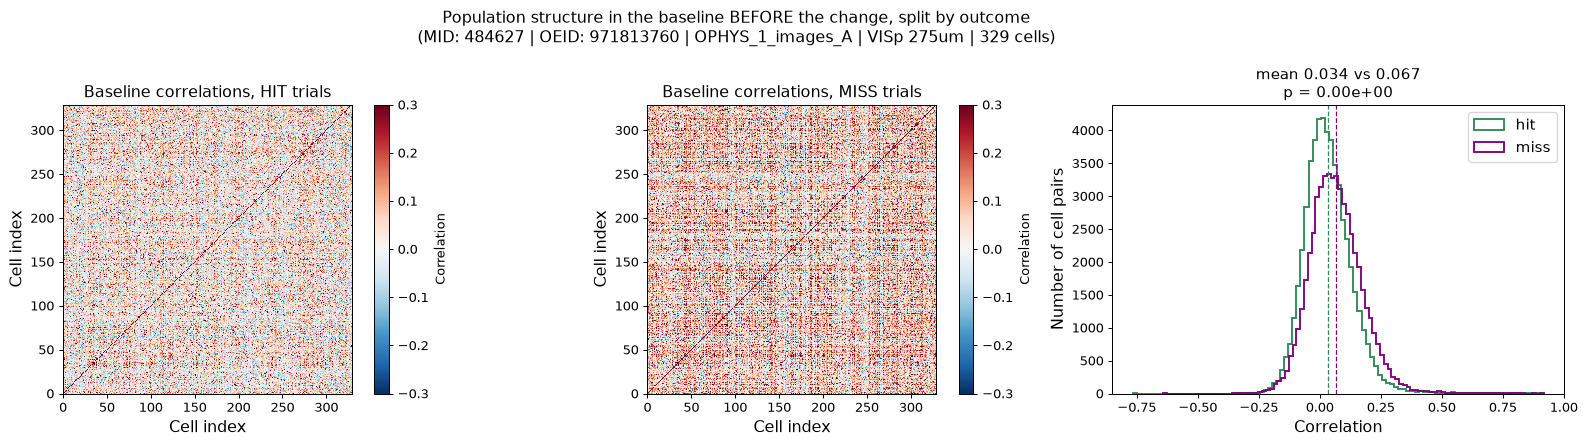

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(19, 5))

for panel, (matrix, label) in enumerate([(correlations_hit, "Baseline correlations, HIT trials"),
                                         (correlations_miss, "Baseline correlations, MISS trials")]):
    mesh = ax[panel].pcolormesh(matrix, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    ax[panel].set_xlabel("Cell index", fontsize=13)
    ax[panel].set_ylabel("Cell index", fontsize=13)
    ax[panel].set_title(label, fontsize=13)
    ax[panel].axis("square")
    fig.colorbar(mesh, ax=ax[panel], label="Correlation", fraction=0.046)

t_outcome, p_outcome = stats.ttest_ind(correlations_hit_flat, correlations_miss_flat,
                                      nan_policy="omit")

ax[2].hist(correlations_hit_flat, bins=100, color="seagreen", label="hit", histtype="step", lw=1.5)
ax[2].hist(correlations_miss_flat, bins=100, color="purple", label="miss", histtype="step", lw=1.5)
ax[2].axvline(np.nanmean(correlations_hit_flat), color="seagreen", ls="--", lw=1)
ax[2].axvline(np.nanmean(correlations_miss_flat), color="purple", ls="--", lw=1)
ax[2].set_xlabel("Correlation", fontsize=13)
ax[2].set_ylabel("Number of cell pairs", fontsize=13)
ax[2].legend(fontsize=12)
ax[2].set_title("mean %.3f vs %.3f\np = %.2e"
                % (np.nanmean(correlations_hit_flat), np.nanmean(correlations_miss_flat),
                   p_outcome), fontsize=12)

fig.suptitle("Population structure in the baseline BEFORE the change, split by outcome\n"
             f"({title_template})", fontsize=13)
fig.tight_layout()

print("mean correlation hit:  %.4f" % np.nanmean(correlations_hit_flat))
print("mean correlation miss: %.4f" % np.nanmean(correlations_miss_flat))
print("t = %.2f, p = %.3e" % (t_outcome, p_outcome))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Reading this result carefully</h3>

Baseline correlations are **higher before misses than before hits**. Taken at face value: on
trials where the mouse failed to report the change, the population was already in a more
globally coupled state a half-second before the image changed. That is the kind of result that
gets described as a signature of disengagement &mdash; strong shared fluctuation, less independent
information capacity.

Before believing it, note two confounds that this analysis does *not* control for, and that you
should check:

**Unequal trial counts.** There are more hit trials than miss trials, and correlation estimates
computed from fewer samples are noisier and biased in magnitude. Subsample the hit trials to
match the number of misses, repeat many times, and see whether the difference survives.

**Running and arousal.** Mice miss changes when they are disengaged, and disengagement covaries
with running and pupil. If the mouse is stationary before misses and running before hits, you may
be measuring locomotion state rather than anything about task engagement per se. The running
speed is right there in the file &mdash; check it.

**Time in session.** Misses concentrate late in a session as the mouse sates. If correlations also
drift over the session (and section 3.1 suggests they do) then trial time is a confound for
outcome.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Address the unequal-trial-count confound. Subsample the hit trials down to
the number of miss trials, recompute the mean correlation, repeat 100 times, and compare the
resulting distribution to the observed miss value.

Does the hit vs miss difference survive?

</div>

subsampled hit means: 0.0352 +/- 0.0020
observed miss mean:   0.0673

subsamples of hit trials reaching the miss value: 0 / 100
-> the difference is not explained by trial count alone


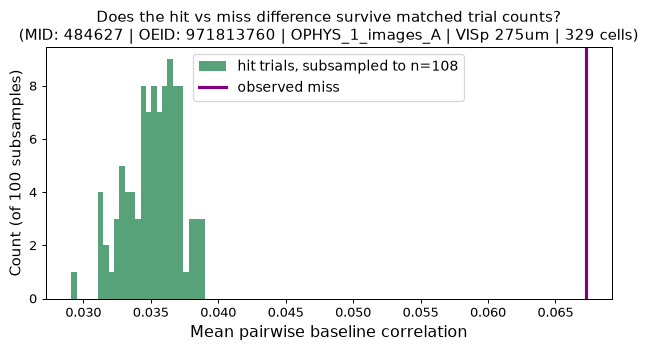

In [49]:
rng = np.random.default_rng(0)

n_miss_trials = matrix_miss.shape[1]
n_iterations = 100

subsampled_means = []
for _ in range(n_iterations):
    trial_subset = rng.choice(matrix_hit.columns.values, size=n_miss_trials, replace=False)
    subsampled_matrix = matrix_hit[trial_subset]
    subsampled_correlations = np.corrcoef(subsampled_matrix.values)
    subsampled_means.append(np.nanmean(subsampled_correlations[upper_triangle_outcome]))

subsampled_means = np.array(subsampled_means)
observed_miss_mean = np.nanmean(correlations_miss_flat)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(subsampled_means, bins=25, color="seagreen", alpha=0.8,
        label=f"hit trials, subsampled to n={n_miss_trials}")
ax.axvline(observed_miss_mean, color="purple", lw=2.5, label="observed miss")
ax.set_xlabel("Mean pairwise baseline correlation", fontsize=13)
ax.set_ylabel("Count (of %d subsamples)" % n_iterations, fontsize=12)
ax.legend(fontsize=11)
ax.set_title(f"Does the hit vs miss difference survive matched trial counts?\n({title_template})",
             fontsize=12)
fig.tight_layout()

print("subsampled hit means: %.4f +/- %.4f" % (subsampled_means.mean(), subsampled_means.std()))
print("observed miss mean:   %.4f" % observed_miss_mean)
print()
n_exceeding = int(np.sum(subsampled_means >= observed_miss_mean))
print("subsamples of hit trials reaching the miss value: %d / %d" % (n_exceeding, n_iterations))
if n_exceeding == 0:
    print("-> the difference is not explained by trial count alone")
else:
    print("-> trial count may account for some or all of the difference")

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now address the running confound. Compare the mean running speed in the
0.5&nbsp;s baseline window before hits versus before misses.

If they differ, what does that do to your interpretation of the correlation result?

</div>

mean running before hits:   28.90 cm/s
mean running before misses: 16.18 cm/s
t = 9.06, p = 5.381e-17

median time in session, hits:   30.0 min
median time in session, misses: 55.1 min


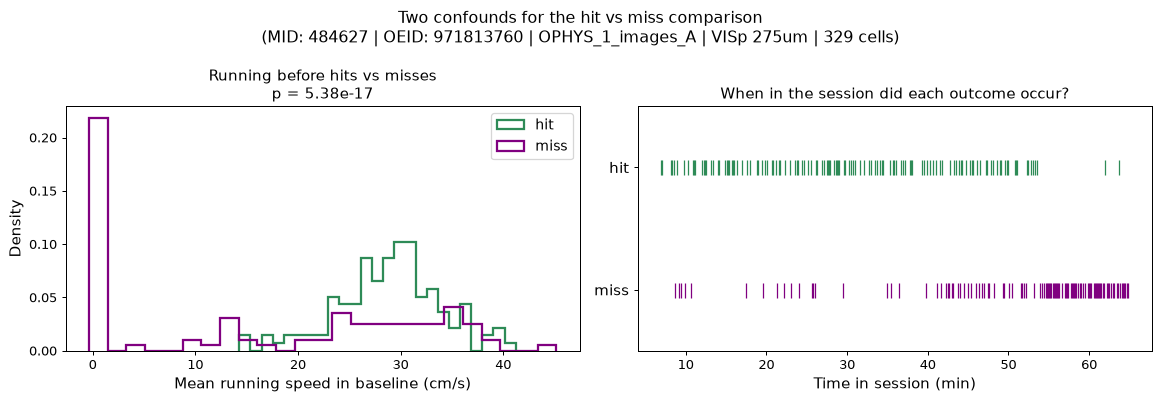

In [50]:
def mean_running_in_baseline(alignment_times, window=0.5):
    """Mean running speed in the `window` seconds before each alignment time."""
    means = []
    for alignment_time in alignment_times:
        in_window = ((running_timestamps >= alignment_time - window)
                     & (running_timestamps < alignment_time))
        means.append(np.nan if in_window.sum() == 0 else running_speed[in_window].mean())
    return np.array(means)


running_before_hit = mean_running_in_baseline(hit_change_times)
running_before_miss = mean_running_in_baseline(miss_change_times)

t_running, p_running = stats.ttest_ind(running_before_hit, running_before_miss,
                                      nan_policy="omit")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].hist(running_before_hit, bins=25, color="seagreen", histtype="step", lw=1.8,
           density=True, label="hit")
ax[0].hist(running_before_miss, bins=25, color="purple", histtype="step", lw=1.8,
           density=True, label="miss")
ax[0].set_xlabel("Mean running speed in baseline (cm/s)", fontsize=12)
ax[0].set_ylabel("Density", fontsize=12)
ax[0].legend(fontsize=11)
ax[0].set_title("Running before hits vs misses\np = %.2e" % p_running, fontsize=12)

# time in session, the other confound
ax[1].plot(hit_change_times / 60, np.ones(len(hit_change_times)), "|",
           color="seagreen", ms=12, label="hit")
ax[1].plot(miss_change_times / 60, np.zeros(len(miss_change_times)), "|",
           color="purple", ms=12, label="miss")
ax[1].set_yticks([0, 1])
ax[1].set_yticklabels(["miss", "hit"], fontsize=12)
ax[1].set_xlabel("Time in session (min)", fontsize=12)
ax[1].set_ylim(-0.5, 1.5)
ax[1].set_title("When in the session did each outcome occur?", fontsize=12)

fig.suptitle(f"Two confounds for the hit vs miss comparison\n({title_template})", fontsize=13)
fig.tight_layout()

print("mean running before hits:   %.2f cm/s" % np.nanmean(running_before_hit))
print("mean running before misses: %.2f cm/s" % np.nanmean(running_before_miss))
print("t = %.2f, p = %.3e" % (t_running, p_running))
print()
print("median time in session, hits:   %.1f min" % (np.median(hit_change_times) / 60))
print("median time in session, misses: %.1f min" % (np.median(miss_change_times) / 60))

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Wrapping up</h1>

What you built, and what it is good for:

**Question 1.** You opened an NWB file with nothing but `h5py`, worked out what was in it, and
reproduced another group's summary figures. The pattern generalizes: `read_nwb_table` will read
any NWB dynamic table, and the block-shading idiom works for any session with a block structure.

**Question 2.** You extracted discrete event times from calcium event detection and treated them
like spike times, which let you reuse the standard raster/PSTH machinery. The important result
was not the population PSTH &mdash; it was that no single trial and no single cell looks like it.
You then did the same alignment on dF/F with `event_triggered_response`, and saw that the choice
of signal changes the apparent smoothness of the response.

**Question 3.** You compared population correlation structure across conditions two ways: over
time within matched spontaneous windows, and over trials split by behavioral outcome. In both
cases the raw comparison gave a large, "highly significant" difference &mdash; and in both cases the
p-value was close to meaningless because cell pairs are not independent. The interesting work was
in the confounds.

<h3>Where to take this next</h3>

- **Across planes.** This file is one of eight simultaneously recorded planes
  (`ophys_session_id` = 971632311, four depths in VISp and four in VISl). Do correlations
  differ within versus across areas? Within versus across depths?
- **Across sessions.** Cells are matched across sessions within an `ophys_container_id`. The same
  neurons appear in the familiar and novel image sessions. Does the change response of a given
  cell change with experience?
- **Across cell types.** This mouse is `Slc17a7`, excitatory. The dataset also has `Vip` and
  `Sst` inhibitory lines. Do the PSTHs and the correlation structure look different?
- **Better statistics.** Build a proper null for the correlation comparisons, by shuffling trial
  labels or circularly shifting traces, instead of relying on a t-test over dependent pairs.

</div>

In [51]:
nwb.close()